# Privacy-Preserving NZSL/BSL Fingerspelling Recognition with Routed One-Hand and Two-Hand Models

This notebook builds a privacy-preserving fingerspelling recognition pipeline using MediaPipe hand skeleton keypoints. Raw images are used only for keypoint extraction and are not retained as model input.

The updated system trains separate one-hand and two-hand versions of each classifier. During live webcam prediction, the backend automatically routes the incoming 508-dimensional keypoint vector to the correct model version based on whether one or two hands are detected.

Main workflow:

1. Load BSL/NZSL-style fingerspelling image folders.
2. Extract MediaPipe hand keypoints into a fixed 508-dimensional feature vector.
3. Split extracted data into one-hand and two-hand groups.
4. Train separate routed models:
   - SVM one-hand / SVM two-hand
   - Random Forest one-hand / Random Forest two-hand
   - k-NN one-hand / k-NN two-hand
   - sklearn MLP one-hand / sklearn MLP two-hand
   - Keras MLP one-hand / Keras MLP two-hand
5. Compare routed keypoint models against a raw-pixel SVM baseline for privacy-vs-accuracy analysis.
6. Export routed model checkpoints for the FastAPI backend.
7. Generate skeleton reference images for the web demo.
8. Run a routed sanity check to confirm the correct one-hand/two-hand checkpoint is selected.

---
## Section 1 — Configuration

Three independent cells — re-run any one without touching the others:

- **1a — Data & preprocessing:** dataset path, class lists, split ratios, MediaPipe settings, parallelism
- **1b — Model hyperparameters:** per-model settings for SVM, RF, k-NN, sklearn MLP, and Keras MLP
- **1c — Analysis & export:** visualisation classes, hard-pair list, raw-pixel baseline, export metadata

## Dataset structure

The image dataset must be stored in the following structure:

```text
data/raw/BSL_Dataset/
├── 1_HAND_DATASET/
│   ├── C/
│   ├── 0/
│   ├── 1/
│   └── ... 9/
└── 2_HAND_DATASET/
    ├── A/
    ├── B/
    ├── D/
    └── ... 10/

In [5]:
import multiprocessing
from pathlib import Path

# ── Project root — resolve regardless of where the kernel starts ──────────────
# VSCode Jupyter injects __vsc_ipynb_file__ with the notebook's absolute path.
# .parent = notebook/   .parent.parent = project root
# Fallback covers Kaggle / Colab / plain Jupyter where CWD is already the root.
try:
    _PROJECT_ROOT = Path(__vsc_ipynb_file__).resolve().parent.parent
except NameError:
    _PROJECT_ROOT = Path().resolve()

# ── Dataset path ──────────────────────────────────────────────────────────────
#changes: Use project-relative dataset path instead of a hardcoded user path.
# Your dataset should be saved at:
# project_root/data/raw/BSL_Dataset/
DATASET_DIR = _PROJECT_ROOT / 'data' / 'raw' / 'BSL_Dataset'

# Expected subfolder structure inside DATASET_DIR:
#   2_HAND_DATASET/   ← classes that use both hands  (A, B, D … Z, 10)
#     A/  B/  D/ ...
#   1_HAND_DATASET/   ← classes that use only one hand  (C, 0–9)
#     C/  0/  1/ ...

# ── Class lists ───────────────────────────────────────────────────────────────
# To add a class: append the label string to the correct list, then move or add
# a matching subfolder under 2_HAND_DATASET/ or 1_HAND_DATASET/.
# J and Y are excluded (dynamic/movement signs); H is not in this dataset.
TWO_HAND_CLASSES = [
    'A','B','D','E','F','G','I','K',
    'L','M','N','O','P','Q','R','S','T','U',
    'V','W','X','Z','10'
]

ONE_HAND_CLASSES = ['C', '0', '1', '2', '3', '4', '5', '6', '7', '8', '9']

# Keep full class list for charts and overall reporting.
ALL_CLASSES = TWO_HAND_CLASSES + ONE_HAND_CLASSES

# ── Image file extensions recognised during dataset indexing ──────────────────
IMG_EXTS = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}

# ── Sampling ──────────────────────────────────────────────────────────────────
MAX_SAMPLES_PER_CLASS = None  # None = use all images in each class folder
                               # int (e.g. 50) = cap per class for fast debug runs;
                               # images are drawn by random shuffle seeded by RANDOM_STATE

# ── Reproducibility ───────────────────────────────────────────────────────────
RANDOM_STATE = 42

# ── Train / val / test fractions ──────────────────────────────────────────────
TEST_SIZE = 0.15
VAL_SIZE  = 0.15

# ── Output and checkpoint folders — always at project root ────────────────────
OUTPUTS_DIR     = _PROJECT_ROOT / 'outputs'
DATA_DIR        = OUTPUTS_DIR / 'data'
RESULTS_DIR     = OUTPUTS_DIR / 'results'
FIGURES_DIR     = OUTPUTS_DIR / 'figures'
CHECKPOINTS_DIR = _PROJECT_ROOT / 'checkpoints'

CACHE_CSV = DATA_DIR / 'dataset.csv'   # extracted 508-dim feature table

#added: Make sure required folders exist before the notebook writes outputs.
OUTPUTS_DIR.mkdir(parents=True, exist_ok=True)
DATA_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
CHECKPOINTS_DIR.mkdir(parents=True, exist_ok=True)

# ── MediaPipe Hands ───────────────────────────────────────────────────────────
MP_DETECTION_CONF = 0.75
MP_MAX_HANDS = 2

# ── Processing / parallelism ──────────────────────────────────────────────────
N_JOBS = max(1, multiprocessing.cpu_count() - 1)

# ── GridSearchCV shared settings ──────────────────────────────────────────────
GRID_CV = 3

print("Project root:", _PROJECT_ROOT)
print("Dataset directory:", DATASET_DIR)
print("Outputs directory:", OUTPUTS_DIR)
print("Checkpoints directory:", CHECKPOINTS_DIR)

Project root: C:\Users\singh\Desktop\a2 i&v\edited code files
Dataset directory: C:\Users\singh\Desktop\a2 i&v\edited code files\data\raw\BSL_Dataset
Outputs directory: C:\Users\singh\Desktop\a2 i&v\edited code files\outputs
Checkpoints directory: C:\Users\singh\Desktop\a2 i&v\edited code files\checkpoints


### 1b — Model hyperparameters
Per-model settings for all four classifiers. Re-run only this cell to adjust model settings without touching data or analysis config.

In [6]:
# ── SVM ───────────────────────────────────────────────────────────────────────
SVM_KERNEL       = 'rbf'        # kernel function: 'rbf' | 'linear' | 'poly' | 'sigmoid'
SVM_GAMMA        = 'scale'      # kernel coefficient: 'scale' | 'auto' | float
SVM_CLASS_WEIGHT = 'balanced'   # up-weight minority classes; None to disable
SVM_PARAM_GRID   = {'clf__C': [0.1, 1, 10, 100]}   # C values searched in Section 8

# ── Random Forest ─────────────────────────────────────────────────────────────
RF_N_ESTIMATORS     = 400
RF_MAX_DEPTH        = None   # None = grow until leaves are pure; int = cap depth
RF_MIN_SAMPLES_LEAF = 1      # minimum samples required at each leaf node
RF_CLASS_WEIGHT     = 'balanced_subsample'   # rebalance within each bootstrap sample; None to disable

# ── k-NN ──────────────────────────────────────────────────────────────────────
KNN_WEIGHTS    = 'distance'     # 'distance' = nearer neighbours count more; 'uniform' = equal
KNN_METRIC     = 'minkowski'    # distance metric (minkowski with p=2 = Euclidean)
KNN_PARAM_GRID = {'clf__n_neighbors': [3, 5, 7, 11, 15]}   # k values searched in Section 8

# ── sklearn MLP ───────────────────────────────────────────────────────────────
# Note: sklearn MLP does not support class_weight — use MAX_SAMPLES_PER_CLASS
# to cap majority classes if imbalance is severe.
SKLEARN_MLP_HIDDEN_LAYERS = (256, 128, 64)   # number of neurons per hidden layer
SKLEARN_MLP_ACTIVATION    = 'relu'           # activation function for hidden layers
SKLEARN_MLP_SOLVER        = 'adam'           # optimiser: 'adam' | 'sgd' | 'lbfgs'
SKLEARN_MLP_LR            = 0.001            # initial learning rate for the adam/sgd solver
SKLEARN_MLP_ALPHA         = 1e-4             # L2 regularisation strength
SKLEARN_MLP_MAX_ITER      = 300              # maximum training epochs

# ── Keras MLP ─────────────────────────────────────────────────────────────────
KERAS_MLP_HIDDEN_LAYERS    = (256, 128, 64)  # neurons per hidden layer; also controls depth
                                              # e.g. (512, 256, 128, 64) adds a fourth layer
KERAS_MLP_DROPOUT          = 0.3             # dropout fraction after each hidden layer except the last
                                              # increase if overfitting; decrease if underfitting
KERAS_MLP_LR               = 0.001           # Adam learning rate
KERAS_MLP_EPOCHS           = 20              # maximum training epochs
KERAS_MLP_BATCH_SIZE       = 32              # samples per gradient update
KERAS_MLP_USE_CLASS_WEIGHT = True            # True = compute balanced class weights from training data
                                              # False = treat all classes equally

# ── Keras early stopping ──────────────────────────────────────────────────────
KERAS_MLP_EARLY_STOPPING = True   # True = stop when val_loss stops improving
KERAS_MLP_PATIENCE       = 4       # epochs with no improvement before stopping

### 1c — Analysis & export settings
Parameters for skeleton visualisation, hard-pair analysis, raw-pixel baseline, and export metadata. Re-run only this cell to adjust analysis settings without touching data or model config.

In [7]:
# ── Raw-pixel baseline ────────────────────────────────────────────────────────
# Kept for report/presentation comparison against keypoint-based models.
# It is not part of the live routed website system yet.
PIXEL_SIZE = (64, 64)
PCA_COMPONENTS = 200
PIXEL_SVM_C = 5
PIXEL_SVM_KERNEL = 'rbf'
PIXEL_SVM_GAMMA = 'scale'

# ── Visualisation and analysis ────────────────────────────────────────────────
VIZ_CLASSES = ['M', 'N', 'R']

# Hard-pair analysis for visually similar signs.
# These are mainly two-hand signs in this dataset.
HARD_PAIRS = [('M', 'N'), ('R', 'U'), ('S', 'E'), ('D', 'G')]

TOP_N_FEATURES = 30

# ── Quality report thresholds ─────────────────────────────────────────────────
QUALITY_GOOD_THRESHOLD = 95
QUALITY_OK_THRESHOLD   = 80

# ── Data output paths ─────────────────────────────────────────────────────────
REPORT_CSV  = RESULTS_DIR / 'extraction_report.csv'
DROPPED_CSV = RESULTS_DIR / 'dropped_images.csv'

#added: Separate output files for routed one-hand/two-hand training evidence.
ONE_HAND_RESULTS_CSV = RESULTS_DIR / 'one_hand_model_results.csv'
TWO_HAND_RESULTS_CSV = RESULTS_DIR / 'two_hand_model_results.csv'
ROUTED_RESULTS_CSV   = RESULTS_DIR / 'one_hand_two_hand_model_results.csv'

# ── Model checkpoint paths ────────────────────────────────────────────────────
#changes: Checkpoints now use one-hand/two-hand routed model names.
# Example:
#   svm_rbf_one_hand.joblib
#   svm_rbf_two_hand.joblib

MODEL_KEYS = ['svm_rbf', 'random_forest', 'knn', 'mlp_sklearn']
HAND_GROUPS = ['one_hand', 'two_hand']

def routed_checkpoint_path(model_key, hand_group):
    return CHECKPOINTS_DIR / f'{model_key}_{hand_group}.joblib'

#added: JSON file used later by backend /models endpoint.
MODEL_RESULTS_JSON = CHECKPOINTS_DIR / 'model_results.json'

# ── Legacy / optional paths from earlier version ──────────────────────────────
# Kept only so older cells do not crash while we replace them step-by-step.
# These are not the main routed checkpoints anymore.
MODEL_JOBLIB = CHECKPOINTS_DIR / 'nzsl_privacy_model.joblib'
MODEL_KERAS  = CHECKPOINTS_DIR / 'bsl_sign_model.h5'
MODEL_LABELS = CHECKPOINTS_DIR / 'label_classes.npy'
KERAS_SCALER = CHECKPOINTS_DIR / 'scaler.pkl'

# Create output folders automatically if they do not exist.
OUTPUTS_DIR.mkdir(parents=True, exist_ok=True)
DATA_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
CHECKPOINTS_DIR.mkdir(parents=True, exist_ok=True)

# ── Export metadata ───────────────────────────────────────────────────────────
# Feature format is still 508-dim so the frontend/backend structure stays compatible.
FEATURE_VERSION = 'v2_routed_one_two_hand_508dim'

print("Raw-pixel baseline kept for report comparison.")
print("Routed model checkpoints will be saved as:")
for model_key in MODEL_KEYS:
    for hand_group in HAND_GROUPS:
        print(" -", routed_checkpoint_path(model_key, hand_group).name)

Raw-pixel baseline kept for report comparison.
Routed model checkpoints will be saved as:
 - svm_rbf_one_hand.joblib
 - svm_rbf_two_hand.joblib
 - random_forest_one_hand.joblib
 - random_forest_two_hand.joblib
 - knn_one_hand.joblib
 - knn_two_hand.joblib
 - mlp_sklearn_one_hand.joblib
 - mlp_sklearn_two_hand.joblib


---
## Section 2 — Imports

In [8]:
# If running on Colab / Kaggle, uncomment the line below:
# !pip -q install mediapipe opencv-python scikit-learn joblib seaborn

import cv2
import math
import joblib
import numpy as np
import pandas as pd
import seaborn as sns
import mediapipe as mp
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, f1_score, confusion_matrix, classification_report
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.utils.class_weight import compute_class_weight

from tensorflow import keras
from tensorflow.keras import layers

sns.set_theme(style='whitegrid')
np.random.seed(RANDOM_STATE)

---
## Section 3 — Keypoint Extraction Functions

Each image is converted into a privacy-preserving 508-dimensional keypoint feature vector.

For each detected hand, the notebook extracts:

- 42 wrist-relative x/y landmark coordinates,
- 210 pairwise landmark distances,
- 2 hand-orientation values.

Each hand produces a **254-dimensional vector**: 42 wrist-relative coordinates + 210 pairwise distances + 2 orientation values.  
Two hands concatenated → **508-dimensional feature vector**.

One-handed signs (e.g. C) have the absent hand **zero-padded** — the slot is filled with 254 zeros rather than dropping the sample. This keeps every class at a consistent 508-dim vector regardless of how many hands are used.


In [9]:
mp_hands = mp.solutions.hands


def _pairwise_distances(points):
    """All pairwise Euclidean distances between 2-D landmark points."""
    dists = []
    n = len(points)
    for i in range(n):
        for j in range(i + 1, n):
            dists.append(np.linalg.norm(points[i] - points[j]))
    return np.array(dists, dtype=np.float32)  # 21*20/2 = 210 values


def _hand_orientation(wrist, index_mcp, pinky_mcp):
    """Sin/cos of the angle between index-MCP and pinky-MCP vectors from wrist."""
    v1 = index_mcp - wrist
    v2 = pinky_mcp - wrist
    cross_z = v1[0] * v2[1] - v1[1] * v2[0]
    angle = math.atan2(cross_z, np.dot(v1, v2))
    return np.array([math.sin(angle), math.cos(angle)], dtype=np.float32)


def _normalize_landmarks(landmarks_xy):
    """Wrist-relative translation + palm-scale normalisation."""
    wrist = landmarks_xy[0]
    rel   = landmarks_xy - wrist
    scale = np.linalg.norm(landmarks_xy[9] - wrist) + 1e-6  # wrist → middle MCP
    rel   = rel / scale
    return (
        rel.flatten(),                               # 42 values
        _pairwise_distances(rel),                   # 210 values
        _hand_orientation(rel[0], rel[5], rel[17])  # 2 values
    )


def count_hands_from_features(features):
    """
    #added: Count how many hand slots are actually present in a 508-dim feature vector.

    The first 254 values represent the left-hand slot.
    The last 254 values represent the right-hand slot.
    If a slot is all zeros, that hand was not detected.
    """
    feats = np.asarray(features, dtype=np.float32)

    if feats.shape[0] != 508:
        raise ValueError(f"Expected 508 features, got {feats.shape[0]}")

    left_present  = np.any(np.abs(feats[:254]) > 1e-8)
    right_present = np.any(np.abs(feats[254:]) > 1e-8)

    return int(left_present) + int(right_present)


def infer_hand_group_from_features(features):
    """
    #added: Infer whether the extracted features should use one-hand or two-hand routing.
    """
    n_hands = count_hands_from_features(features)

    if n_hands <= 1:
        return "one_hand"
    return "two_hand"


def extract_feature_vector_from_image(image_bgr, hands_detector):
    """
    Run MediaPipe Hands on one BGR image.
    Returns a 508-dim float32 vector, or None if no hands are detected at all.

    One-handed signs: the absent hand slot is zero-padded to 254 zeros.
    Two-handed signs: both slots should contain real landmark data.
    The feature vector is always 508-dim regardless of hand count.
    """
    rgb    = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
    result = hands_detector.process(rgb)

    if not result.multi_hand_landmarks:
        return None  # no hands detected at all → drop

    handed = {'Left': None, 'Right': None}

    for hand_lm, handedness in zip(result.multi_hand_landmarks, result.multi_handedness):
        label = handedness.classification[0].label
        pts   = np.array([[lm.x, lm.y] for lm in hand_lm.landmark], dtype=np.float32)

        rel_flat, pairwise, orient = _normalize_landmarks(pts)
        handed[label] = np.concatenate([rel_flat, pairwise, orient])

    empty = np.zeros(254, dtype=np.float32)
    left  = handed['Left']  if handed['Left']  is not None else empty
    right = handed['Right'] if handed['Right'] is not None else empty

    features = np.concatenate([left, right]).astype(np.float32)

    return features

---
## Section 4 — Skeleton Visualisation

> **Privacy note:** Raw pixel data is discarded immediately after keypoint extraction (`del image`). Only the 508-dimensional skeleton vector is retained for training.

**Two visualisations are produced below:**

1. **Full class grid** — one sample skeleton for every class in `ALL_CLASSES` so you can see exactly what MediaPipe extracts per sign. This is what the model actually trains on — no face, no background, no clothing.
2. **Side-by-side detail** — original photo (left) vs skeleton on black canvas (right) for `VIZ_CLASSES`. Shows the privacy contrast: the right panel contains zero identity information.

In [10]:
# ── Visualisation 1: Full class grid — skeleton for every class ───────────────
# Finds the best representative image per class — one where the expected number
# of hands is detected (2 for two-handed classes, 1 for one-handed classes).
# Scans up to SAMPLE_SCAN_LIMIT images per class and picks the first that meets
# the target, falling back to the best found if none does within the limit.

mp_draw   = mp.solutions.drawing_utils
mp_styles = mp.solutions.drawing_styles

CANVAS_SIZE       = 600   # pixels — larger canvas = finer keypoint rendering
SAMPLE_SCAN_LIMIT = 30    # max images to scan per class when hunting for best sample

# Expected hand count per class
expected_hands = {cls: 2 for cls in TWO_HAND_CLASSES}
expected_hands.update({cls: 1 for cls in ONE_HAND_CLASSES})

# Collect candidate image paths per class (sorted for reproducibility)
class_image_lists = {}
for cls in ALL_CLASSES:
    subfolder = '2_HAND_DATASET' if cls in TWO_HAND_CLASSES else '1_HAND_DATASET'
    cls_dir = DATASET_DIR / subfolder / cls
    if cls_dir.exists():
        imgs = sorted([p for p in cls_dir.rglob('*') if p.suffix.lower() in IMG_EXTS])
        if imgs:
            class_image_lists[cls] = [str(p) for p in imgs]

missing = [c for c in ALL_CLASSES if c not in class_image_lists]
if missing:
    print(f'[WARN] No sample images found for classes: {missing}')

# ── Select best sample per class ─────────────────────────────────────────────
# For each class, scan up to SAMPLE_SCAN_LIMIT images and pick the first where
# MediaPipe detects the expected number of hands.  Falls back to the image with
# the most hands detected if the target is not met within the scan limit.
class_samples  = {}   # cls → (image_path, canvas, hands_found)

with mp_hands.Hands(
    static_image_mode=True,
    max_num_hands=MP_MAX_HANDS,
    min_detection_confidence=MP_DETECTION_CONF
) as hands:
    for cls in ALL_CLASSES:
        if cls not in class_image_lists:
            continue

        target   = expected_hands.get(cls, 1)
        best_img = None
        best_canvas = None
        best_count  = -1

        for img_path in class_image_lists[cls][:SAMPLE_SCAN_LIMIT]:
            img_bgr = cv2.imread(img_path)
            if img_bgr is None:
                continue
            img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
            result  = hands.process(img_rgb)
            del img_bgr, img_rgb

            n_detected = len(result.multi_hand_landmarks) if result.multi_hand_landmarks else 0

            # Draw this candidate on a canvas
            img_bgr2 = cv2.imread(img_path)
            img_rgb2 = cv2.cvtColor(img_bgr2, cv2.COLOR_BGR2RGB)
            canvas   = np.zeros((CANVAS_SIZE, CANVAS_SIZE, 3), dtype=np.uint8)
            if result.multi_hand_landmarks:
                for hand_lm in result.multi_hand_landmarks:
                    mp_draw.draw_landmarks(
                        canvas, hand_lm,
                        mp_hands.HAND_CONNECTIONS,
                        mp_styles.get_default_hand_landmarks_style(),
                        mp_styles.get_default_hand_connections_style()
                    )
            del img_bgr2, img_rgb2

            if n_detected > best_count:
                best_count  = n_detected
                best_canvas = canvas
                best_img    = img_path

            if n_detected >= target:
                break  # found an image meeting the expected hand count

        if best_canvas is not None:
            class_samples[cls] = (best_img, best_canvas, best_count)

# ── Draw the grid ─────────────────────────────────────────────────────────────
n_cols = 6
n_rows = math.ceil(len(ALL_CLASSES) / n_cols)
fig, axes = plt.subplots(n_rows, n_cols,
                         figsize=(n_cols * 4, n_rows * 4.5),
                         dpi=300)
axes = axes.flatten()

for idx, cls in enumerate(ALL_CLASSES):
    ax = axes[idx]
    if cls not in class_samples:
        ax.set_visible(False)
        continue

    _, canvas, hands_found = class_samples[cls]
    target    = expected_hands.get(cls, 1)
    hand_note = f'{hands_found} hand{"s" if hands_found != 1 else ""}'
    # Flag classes where even the best sample didn't meet the expected count
    if hands_found < target:
        hand_note += ' ⚠'

    ax.imshow(canvas)
    ax.set_title(f'{cls}  ({hand_note})', fontsize=10, fontweight='bold',
                 color='white', pad=4)
    ax.set_facecolor('black')
    ax.axis('off')

for idx in range(len(ALL_CLASSES), len(axes)):
    axes[idx].set_visible(False)

fig.patch.set_facecolor('#111111')
plt.suptitle('MediaPipe Skeleton Keypoints — All Classes\n'
             '(this is what the model trains on — no pixels, no identity)\n'
             '⚠ = best sample within scan limit still did not meet expected hand count',
             fontsize=13, color='white', y=1.01)
plt.tight_layout()

out_path = FIGURES_DIR / 'skeleton_all_classes.png'
plt.savefig(out_path, dpi=300, bbox_inches='tight', facecolor=fig.get_facecolor())
print(f'High-res grid saved → {out_path}')
plt.show()

c:\Users\singh\Desktop\a2 i&v\edited code files\.venv\lib\site-packages\google\protobuf\symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '
C:\Users\singh\AppData\Local\Temp\ipykernel_40388\3489275723.py:121: UserWarning: Glyph 9888 (\N{WARNING SIGN}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\singh\AppData\Local\Temp\ipykernel_40388\3489275723.py:124: UserWarning: Glyph 9888 (\N{WARNING SIGN}) missing from font(s) Arial.
  plt.savefig(out_path, dpi=300, bbox_inches='tight', facecolor=fig.get_facecolor())


High-res grid saved → C:\Users\singh\Desktop\a2 i&v\edited code files\outputs\skeleton_all_classes.png


c:\Users\singh\Desktop\a2 i&v\edited code files\.venv\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9888 (\N{WARNING SIGN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


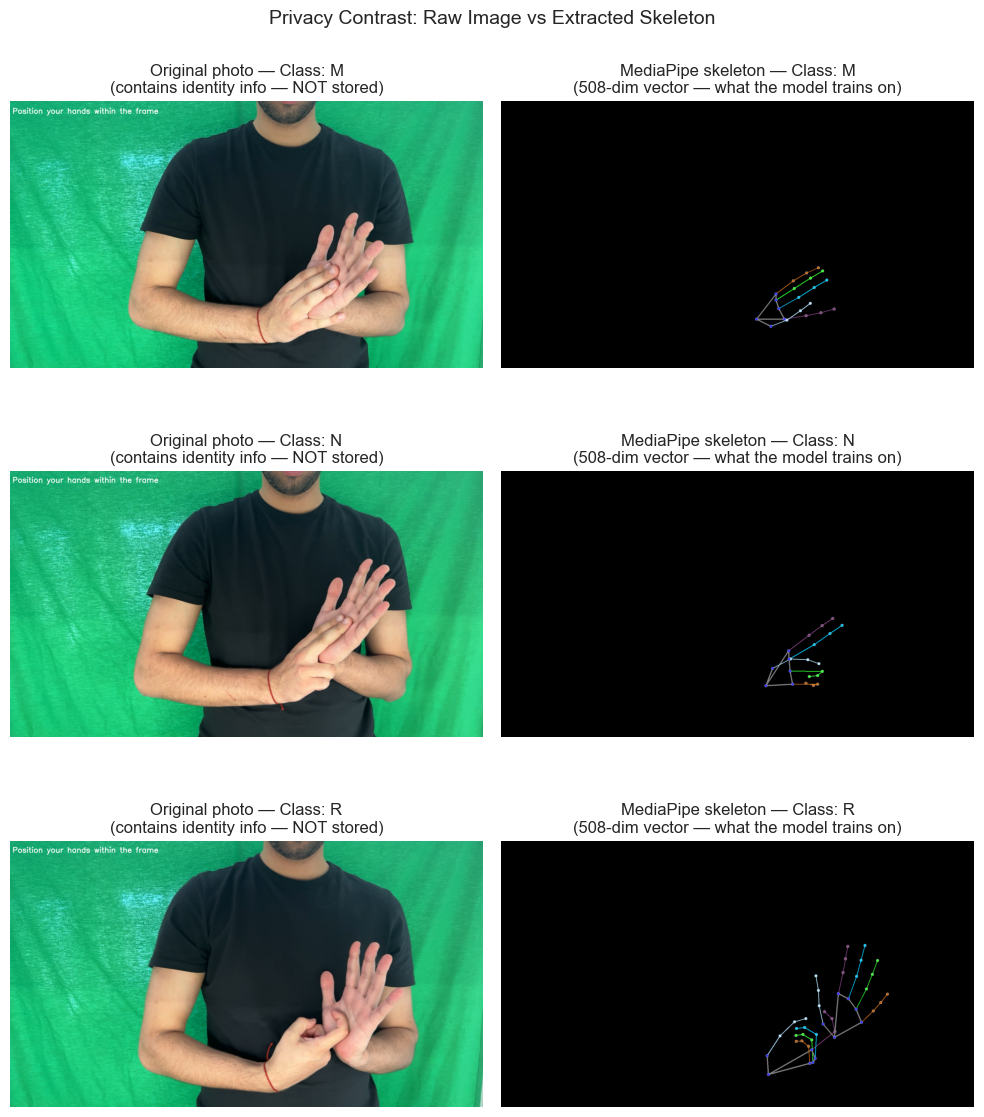

In [11]:
# ── Visualisation 2: Side-by-side — original photo vs skeleton ────────────────
# Left panel = raw photo (what a human sees, contains identity information).
# Right panel = skeleton on black canvas (what the model trains on, no identity).
# Raw frames are deleted immediately after drawing the skeleton.

sample_paths = []
for cls in VIZ_CLASSES:
    subfolder = '2_HAND_DATASET' if cls in TWO_HAND_CLASSES else '1_HAND_DATASET'
    cls_dir = DATASET_DIR / subfolder / cls
    if cls_dir.exists():
        imgs = sorted([p for p in cls_dir.rglob('*') if p.suffix.lower() in IMG_EXTS])
        if imgs:
            sample_paths.append((str(imgs[0]), cls))

if not sample_paths:
    print('No sample images found — check DATASET_DIR in Section 1.')
else:
    fig, axes = plt.subplots(len(sample_paths), 2, figsize=(10, 4 * len(sample_paths)))
    if len(sample_paths) == 1:
        axes = [axes]

    with mp_hands.Hands(
        static_image_mode=True,
        max_num_hands=MP_MAX_HANDS,
        min_detection_confidence=MP_DETECTION_CONF
    ) as hands:
        for i, (img_path, cls) in enumerate(sample_paths):
            img_bgr = cv2.imread(img_path)
            img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
            result  = hands.process(img_rgb)

            # Skeleton on black canvas — the privacy-safe representation
            canvas = np.zeros_like(img_rgb)
            if result.multi_hand_landmarks:
                for hand_lm in result.multi_hand_landmarks:
                    mp_draw.draw_landmarks(
                        canvas, hand_lm,
                        mp_hands.HAND_CONNECTIONS,
                        mp_styles.get_default_hand_landmarks_style(),
                        mp_styles.get_default_hand_connections_style()
                    )

            axes[i][0].imshow(img_rgb)
            axes[i][0].set_title(f'Original photo — Class: {cls}\n(contains identity info — NOT stored)')
            axes[i][0].axis('off')

            axes[i][1].imshow(canvas)
            axes[i][1].set_title(f'MediaPipe skeleton — Class: {cls}\n(508-dim vector — what the model trains on)')
            axes[i][1].axis('off')

            del img_bgr, img_rgb  # discard raw frames — only skeleton canvas kept

    plt.suptitle('Privacy Contrast: Raw Image vs Extracted Skeleton', fontsize=14)
    plt.tight_layout()
    plt.show()

---
## Section 5 — Keypoint dataset creation

This section scans all image folders, extracts MediaPipe hand keypoint features, and saves them into `outputs/dataset.csv`.

The updated routed version also saves:

- `label` — class label,
- `hand_group` — `one_hand` or `two_hand`,
- `detected_hands` — number of hands detected in the extracted feature vector.

Strict hand-count filtering is used:

```text
one-hand classes must detect exactly 1 hand
two-hand classes must detect exactly 2 hands

In [12]:
# ── Keypoint extraction and dataset cache creation ────────────────────────────
#changes: Keep original 508-feature extraction, but also save hand_group and detected_hands.
#added: These extra columns support separate one-hand/two-hand model training later.

_expected_hand_count = {cls: 2 for cls in TWO_HAND_CLASSES}
_expected_hand_count.update({cls: 1 for cls in ONE_HAND_CLASSES})

_class_hand_group = {cls: 'two_hand' for cls in TWO_HAND_CLASSES}
_class_hand_group.update({cls: 'one_hand' for cls in ONE_HAND_CLASSES})


def list_class_images(dataset_dir, classes):
    records = []
    rng = np.random.default_rng(RANDOM_STATE)

    for cls in classes:
        subfolder = '2_HAND_DATASET' if cls in TWO_HAND_CLASSES else '1_HAND_DATASET'
        cls_dir = dataset_dir / subfolder / cls

        if not cls_dir.exists():
            print(f'[WARN] Missing class folder: {cls_dir}')
            continue

        files = sorted([p for p in cls_dir.rglob('*') if p.suffix.lower() in IMG_EXTS])

        if MAX_SAMPLES_PER_CLASS is not None:
            rng.shuffle(files)
            files = files[:MAX_SAMPLES_PER_CLASS]

        records.extend([
            {
                'image_path': str(p),
                'label': cls,
                'hand_group': _class_hand_group[cls],
                'expected_hands': _expected_hand_count[cls]
            }
            for p in files
        ])

    return pd.DataFrame(records)


def build_keypoint_dataset(df_index):
    """
    Extract 508-dim keypoint vectors from all images.

    Hand-count enforcement:
    - one-hand classes must detect at least 1 hand
    - two-hand classes must detect at least 2 hands

    Returns:
        X               (N, 508) float32
        y               (N,) labels
        hand_groups     (N,) one_hand/two_hand
        detected_counts (N,) detected hand count
        class_stats     dict
        dropped_info    list
    """
    X, y, hand_groups, detected_counts = [], [], [], []

    class_stats = {
        cls: {
            'found': 0,
            'extracted': 0,
            'kept_1h': 0,
            'kept_2h': 0,
            'drop_wrong_count': 0,
            'drop_no_hands': 0,
            'drop_load_fail': 0,
            'dropped': 0
        }
        for cls in ALL_CLASSES
    }

    dropped_info = []

    with mp_hands.Hands(
        static_image_mode=True,
        max_num_hands=MP_MAX_HANDS,
        min_detection_confidence=MP_DETECTION_CONF
    ) as hands:

        total = len(df_index)

        for i, row in enumerate(df_index.itertuples(index=False)):
            if i % 2000 == 0:
                print(f'  Processing {i}/{total}...')

            cls = row.label
            expected = int(row.expected_hands)
            hand_group = row.hand_group

            class_stats[cls]['found'] += 1

            image = cv2.imread(row.image_path)

            if image is None:
                class_stats[cls]['drop_load_fail'] += 1
                class_stats[cls]['dropped'] += 1
                dropped_info.append({
                    'path': row.image_path,
                    'label': cls,
                    'hand_group': hand_group,
                    'reason': 'load_failed'
                })
                continue

            feats = extract_feature_vector_from_image(image, hands)
            del image

            if feats is None:
                class_stats[cls]['drop_no_hands'] += 1
                class_stats[cls]['dropped'] += 1
                dropped_info.append({
                    'path': row.image_path,
                    'label': cls,
                    'hand_group': hand_group,
                    'reason': 'no_hands'
                })
                continue

            n_real = count_hands_from_features(feats)

            if n_real != expected:
                class_stats[cls]['drop_wrong_count'] += 1
                class_stats[cls]['dropped'] += 1
                dropped_info.append({
                    'path': row.image_path,
                    'label': cls,
                    'hand_group': hand_group,
                    'reason': f'wrong_hand_count (detected {n_real}, expected {expected})'
                })
                continue

            if n_real == 1:
                class_stats[cls]['kept_1h'] += 1
            else:
                class_stats[cls]['kept_2h'] += 1

            class_stats[cls]['extracted'] += 1

            X.append(feats)
            y.append(cls)
            hand_groups.append(hand_group)
            detected_counts.append(n_real)

    return (
        np.array(X, dtype=np.float32),
        np.array(y),
        np.array(hand_groups),
        np.array(detected_counts),
        class_stats,
        dropped_info
    )


# Index all images
df_index = list_class_images(DATASET_DIR, ALL_CLASSES)

print(f'Total images indexed: {len(df_index)}')

if len(df_index) == 0:
    raise FileNotFoundError(
        f"No images found. Check DATASET_DIR and folder names:\n{DATASET_DIR}"
    )

print("\nImage count by class:")
display(df_index['label'].value_counts().sort_index())

print("\nImage count by hand group:")
display(df_index['hand_group'].value_counts())


# ── Extract and save feature cache ────────────────────────────────────────────
print('\nExtracting keypoints — this may take several minutes...')

X_key, y_key, hand_group_key, detected_hands_key, class_stats, dropped_info = build_keypoint_dataset(df_index)

# Save feature CSV
df_cache = pd.DataFrame(X_key, columns=[f'f_{i}' for i in range(X_key.shape[1])])
df_cache['label'] = y_key
df_cache['hand_group'] = hand_group_key
df_cache['detected_hands'] = detected_hands_key
df_cache.to_csv(CACHE_CSV, index=False)

print(f'\nFeature cache saved to: {CACHE_CSV}')
print(f'Feature cache shape: {df_cache.shape}')

# Build and save per-class stats table
df_stats = pd.DataFrame([
    {
        'class':            cls,
        'hand_group':       _class_hand_group.get(cls, 'unknown'),
        'expected_hands':   _expected_hand_count.get(cls, 1),
        'found':            v['found'],
        'extracted':        v['extracted'],
        'kept_1h':          v['kept_1h'],
        'kept_2h':          v['kept_2h'],
        'drop_wrong_count': v['drop_wrong_count'],
        'drop_no_hands':    v['drop_no_hands'],
        'drop_load_fail':   v['drop_load_fail'],
        'dropped':          v['dropped'],
        'success_pct':      round(v['extracted']        / max(v['found'], 1) * 100, 1),
        'wrong_count_pct':  round(v['drop_wrong_count'] / max(v['found'], 1) * 100, 1),
        'drop_rate_pct':    round(v['dropped']          / max(v['found'], 1) * 100, 1),
    }
    for cls, v in class_stats.items()
])

df_stats.to_csv(REPORT_CSV, index=False)

# Save dropped image log
pd.DataFrame(dropped_info).to_csv(DROPPED_CSV, index=False)

total_dropped     = sum(v['dropped'] for v in class_stats.values())
total_wrong_count = sum(v['drop_wrong_count'] for v in class_stats.values())
total_no_hands    = sum(v['drop_no_hands'] for v in class_stats.values())
total_load_fail   = sum(v['drop_load_fail'] for v in class_stats.values())

print(f'\nExtracted: {X_key.shape[0]} samples  |  Dropped: {total_dropped}')
print(f'  ↳ wrong hand count: {total_wrong_count}  |  no hands detected: {total_no_hands}  |  load failed: {total_load_fail}')
print(f'Quality report saved to {REPORT_CSV}')
print(f'Dropped image log saved to {DROPPED_CSV}')

print("\nExtracted samples by hand group:")
display(df_cache['hand_group'].value_counts())

Total images indexed: 34000

Image count by class:


label
0     1000
1     1000
10    1000
2     1000
3     1000
4     1000
5     1000
6     1000
7     1000
8     1000
9     1000
A     1000
B     1000
C     1000
D     1000
E     1000
F     1000
G     1000
I     1000
K     1000
L     1000
M     1000
N     1000
O     1000
P     1000
Q     1000
R     1000
S     1000
T     1000
U     1000
V     1000
W     1000
X     1000
Z     1000
Name: count, dtype: int64


Image count by hand group:


hand_group
two_hand    23000
one_hand    11000
Name: count, dtype: int64


Extracting keypoints — this may take several minutes...
  Processing 0/34000...


c:\Users\singh\Desktop\a2 i&v\edited code files\.venv\lib\site-packages\google\protobuf\symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '


  Processing 2000/34000...
  Processing 4000/34000...
  Processing 6000/34000...
  Processing 8000/34000...
  Processing 10000/34000...
  Processing 12000/34000...
  Processing 14000/34000...
  Processing 16000/34000...
  Processing 18000/34000...
  Processing 20000/34000...
  Processing 22000/34000...
  Processing 24000/34000...
  Processing 26000/34000...
  Processing 28000/34000...
  Processing 30000/34000...
  Processing 32000/34000...

Feature cache saved to: C:\Users\singh\Desktop\a2 i&v\edited code files\outputs\dataset.csv
Feature cache shape: (27620, 511)

Extracted: 27620 samples  |  Dropped: 6380
  ↳ wrong hand count: 5718  |  no hands detected: 662  |  load failed: 0
Quality report saved to C:\Users\singh\Desktop\a2 i&v\edited code files\outputs\extraction_report.csv
Dropped image log saved to C:\Users\singh\Desktop\a2 i&v\edited code files\outputs\dropped_images.csv

Extracted samples by hand group:


hand_group
two_hand    16989
one_hand    10631
Name: count, dtype: int64

=== Per-Class Extraction Quality Report ===


,class,hand_group,expected_hands,found,extracted,kept_1h,kept_2h,drop_wrong_count,drop_no_hands,drop_load_fail,dropped,success_pct,wrong_count_pct,drop_rate_pct
0,A,two_hand,2,1000,950,0,950,50,0,0,50,95.0%,5.0%,5.0%
1,B,two_hand,2,1000,737,0,737,253,10,0,263,73.7%,25.3%,26.3%
2,D,two_hand,2,1000,860,0,860,133,7,0,140,86.0%,13.3%,14.0%
3,E,two_hand,2,1000,915,0,915,84,1,0,85,91.5%,8.4%,8.5%
4,F,two_hand,2,1000,724,0,724,257,19,0,276,72.4%,25.7%,27.6%
5,G,two_hand,2,1000,784,0,784,205,11,0,216,78.4%,20.5%,21.6%
6,I,two_hand,2,1000,886,0,886,109,5,0,114,88.6%,10.9%,11.4%
7,K,two_hand,2,1000,757,0,757,232,11,0,243,75.7%,23.2%,24.3%
8,L,two_hand,2,1000,766,0,766,221,13,0,234,76.6%,22.1%,23.4%
9,M,two_hand,2,1000,531,0,531,448,21,0,469,53.1%,44.8%,46.9%


Extraction quality plot saved to: C:\Users\singh\Desktop\a2 i&v\edited code files\outputs\extraction_quality_summary.png


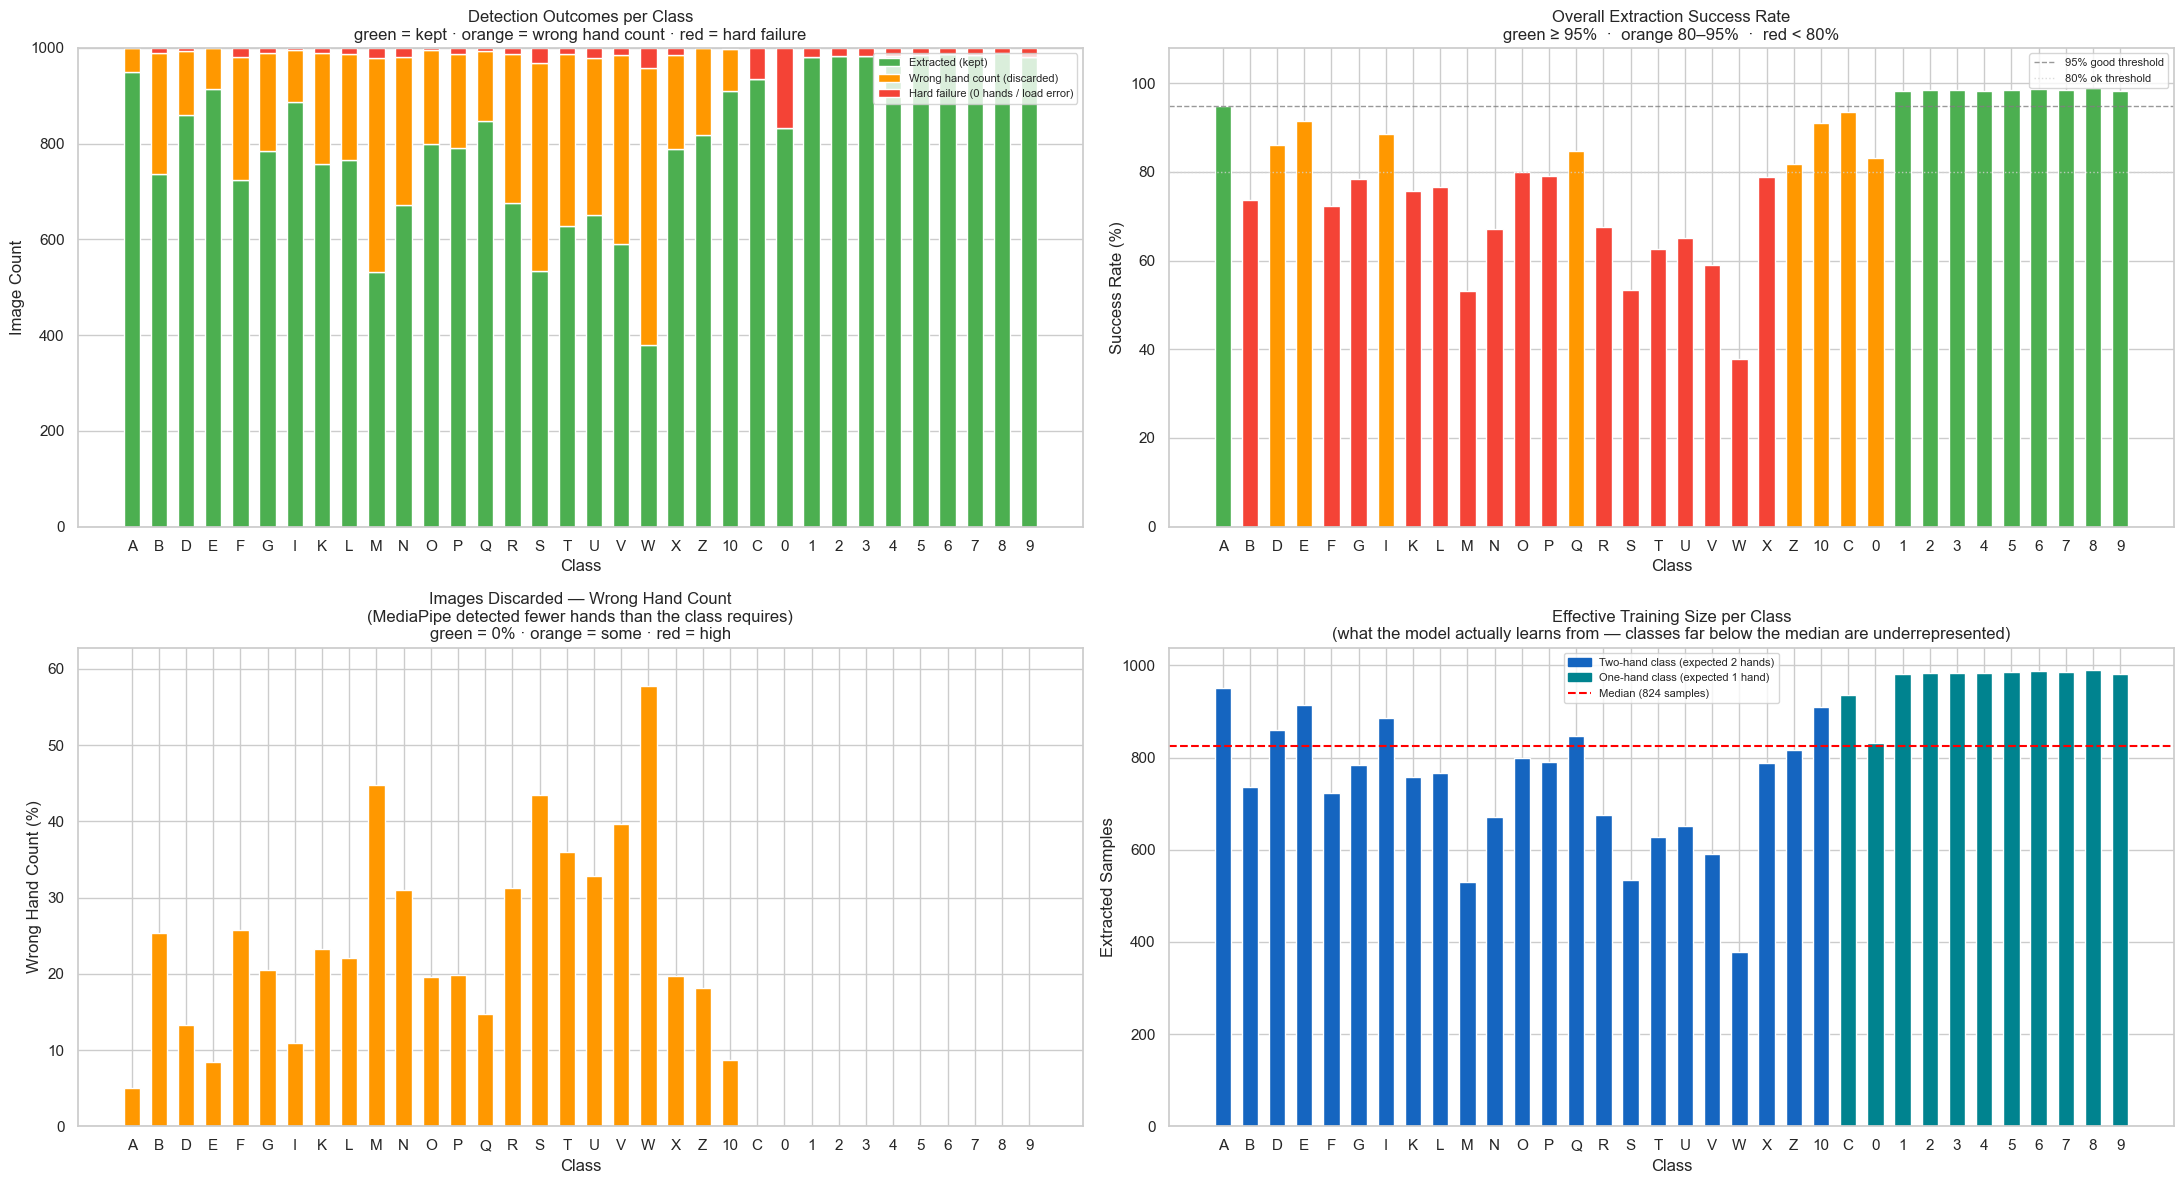


Drop reason breakdown (6380 total dropped images):
reason
wrong_hand_count (detected 1, expected 2)    5718
no_hands                                      662

Full list saved to: C:\Users\singh\Desktop\a2 i&v\edited code files\outputs\dropped_images.csv


In [13]:
# ── Extraction Quality Report ─────────────────────────────────────────────────
# Table columns:
#   expected_hands   — how many hands the class requires (2 or 1)
#   kept_1h/kept_2h  — extracted samples where 1 or 2 hands were detected (post-filter)
#   drop_wrong_count — discarded because detected hands < expected (e.g. 1 found, 2 needed)
#   drop_no_hands    — discarded because MediaPipe found zero hands at all
#   drop_load_fail   — discarded because the image file could not be read
#   dropped          — total of all three drop categories
# Colour thresholds set by QUALITY_GOOD_THRESHOLD and QUALITY_OK_THRESHOLD in Section 1.

from matplotlib.lines import Line2D

if df_stats is not None:
    print('=== Per-Class Extraction Quality Report ===')
    display(
        df_stats.style
            .background_gradient(subset=['success_pct'],     cmap='RdYlGn',   vmin=70, vmax=100)
            .background_gradient(subset=['drop_rate_pct'],   cmap='RdYlGn_r', vmin=0,  vmax=30)
            .background_gradient(subset=['wrong_count_pct'], cmap='RdYlGn_r', vmin=0,  vmax=30)
            .format({
                'success_pct':     '{:.1f}%',
                'drop_rate_pct':   '{:.1f}%',
                'wrong_count_pct': '{:.1f}%',
            })
    )

    fig, axes = plt.subplots(2, 2, figsize=(22, 12))
    axes = axes.flatten()

    x     = np.arange(len(df_stats))
    bar_w = 0.6

    # ── Panel 1 — Detection outcomes: what MediaPipe saw vs what was kept ─────
    # 3 segments stacked per class:
    #   Green  = extracted (kept — met expected hand count)
    #   Orange = drop_wrong_count (MediaPipe found ≥1 hand but fewer than required)
    #   Red    = hard failures (drop_no_hands + drop_load_fail — nothing usable)
    df_hard_fail = df_stats['drop_no_hands'] + df_stats['drop_load_fail']
    bottom_wc    = df_stats['extracted'].values
    bottom_hf    = bottom_wc + df_stats['drop_wrong_count'].values

    axes[0].bar(x, df_stats['extracted'],        color='#4CAF50', label='Extracted (kept)',                    width=bar_w)
    axes[0].bar(x, df_stats['drop_wrong_count'], color='#FF9800', label='Wrong hand count (discarded)',        width=bar_w, bottom=bottom_wc)
    axes[0].bar(x, df_hard_fail,                 color='#F44336', label='Hard failure (0 hands / load error)', width=bar_w, bottom=bottom_hf)
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(df_stats['class'])
    axes[0].set_xlabel('Class')
    axes[0].set_ylabel('Image Count')
    axes[0].set_title('Detection Outcomes per Class\n'
                      'green = kept · orange = wrong hand count · red = hard failure')
    axes[0].legend(loc='upper right', fontsize=8)

    # ── Panel 2 — Overall extraction success rate per class ───────────────────
    bar_colors_2 = [
        '#F44336' if r < QUALITY_OK_THRESHOLD
        else '#FF9800' if r < QUALITY_GOOD_THRESHOLD
        else '#4CAF50'
        for r in df_stats['success_pct']
    ]
    axes[1].bar(x, df_stats['success_pct'], color=bar_colors_2, width=bar_w)
    axes[1].axhline(QUALITY_GOOD_THRESHOLD, color='gray',      linestyle='--', linewidth=1, alpha=0.8,
                    label=f'{QUALITY_GOOD_THRESHOLD}% good threshold')
    axes[1].axhline(QUALITY_OK_THRESHOLD,   color='lightgray', linestyle=':',  linewidth=1, alpha=0.8,
                    label=f'{QUALITY_OK_THRESHOLD}% ok threshold')
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(df_stats['class'])
    axes[1].set_xlabel('Class')
    axes[1].set_ylabel('Success Rate (%)')
    axes[1].set_title(
        f'Overall Extraction Success Rate\n'
        f'green ≥ {QUALITY_GOOD_THRESHOLD}%  ·  '
        f'orange {QUALITY_OK_THRESHOLD}–{QUALITY_GOOD_THRESHOLD}%  ·  '
        f'red < {QUALITY_OK_THRESHOLD}%'
    )
    axes[1].set_ylim(0, 108)
    axes[1].legend(fontsize=8)

    # ── Panel 3 — Wrong hand count rate per class ─────────────────────────────
    wrong_colors = [
        '#4CAF50' if r == 0
        else '#FF9800' if r < QUALITY_OK_THRESHOLD
        else '#F44336'
        for r in df_stats['wrong_count_pct']
    ]
    axes[2].bar(x, df_stats['wrong_count_pct'], color=wrong_colors, width=bar_w)
    axes[2].set_xticks(x)
    axes[2].set_xticklabels(df_stats['class'])
    axes[2].set_xlabel('Class')
    axes[2].set_ylabel('Wrong Hand Count (%)')
    axes[2].set_title(
        'Images Discarded — Wrong Hand Count\n'
        '(MediaPipe detected fewer hands than the class requires)\n'
        'green = 0% · orange = some · red = high'
    )
    axes[2].set_ylim(0, max(df_stats['wrong_count_pct'].max() + 5, 10))

    # ── Panel 4 — Effective training size per class ───────────────────────────
    # The most important panel for model quality: shows class imbalance after
    # extraction.  Classes far below the median will be underrepresented during
    # training, directly hurting the model's accuracy on those signs.
    median_extracted = df_stats['extracted'].median()
    panel4_colors    = [
        '#1565C0' if _expected_hand_count.get(cls, 1) == 2 else '#00838F'
        for cls in df_stats['class']
    ]
    axes[3].bar(x, df_stats['extracted'], color=panel4_colors, width=bar_w)
    axes[3].axhline(median_extracted, color='red', linestyle='--', linewidth=1.5)
    axes[3].set_xticks(x)
    axes[3].set_xticklabels(df_stats['class'])
    axes[3].set_xlabel('Class')
    axes[3].set_ylabel('Extracted Samples')
    axes[3].set_title(
        'Effective Training Size per Class\n'
        '(what the model actually learns from — classes far below the median are underrepresented)'
    )
    axes[3].legend(handles=[
        Patch(color='#1565C0', label='Two-hand class (expected 2 hands)'),
        Patch(color='#00838F', label='One-hand class (expected 1 hand)'),
        Line2D([0], [0], color='red', linestyle='--', linewidth=1.5,
               label=f'Median ({median_extracted:.0f} samples)'),
    ], fontsize=8)

    plt.tight_layout()

    #added: Save extraction quality plot for report/presentation evidence.
    quality_plot_path = FIGURES_DIR / 'extraction_quality_summary.png'
    plt.savefig(quality_plot_path, dpi=300, bbox_inches='tight')
    print(f'Extraction quality plot saved to: {quality_plot_path}')

    plt.show()

    if dropped_info:
        df_dropped = pd.DataFrame(dropped_info)
        print(f'\nDrop reason breakdown ({len(df_dropped)} total dropped images):')
        print(df_dropped['reason'].value_counts().to_string())
        print(f'\nFull list saved to: {DROPPED_CSV}')

else:
    print('No extraction stats available.')
    print('Re-run Section 5 to generate the quality report.')

---
## Section 6 — Load `dataset.csv`

This is the **base-code connection point**. The original `sign-language-bsl.ipynb` loaded a pre-extracted Kaggle CSV here. We now load our own `dataset.csv` — everything else in this section is unchanged from the base code.

In [14]:
#changes: Load updated dataset.csv with metadata columns:
# label, hand_group, detected_hands.
# Feature columns are selected explicitly as f_0 ... f_507.

data = pd.read_csv(
    CACHE_CSV,
    dtype={
        'label': str,
        'hand_group': str
    }
)

# Feature columns only
feature_cols = [c for c in data.columns if c.startswith('f_')]

required_meta_cols = ['label', 'hand_group', 'detected_hands']
missing_meta = [c for c in required_meta_cols if c not in data.columns]

if missing_meta:
    raise ValueError(f'Missing expected metadata columns in dataset.csv: {missing_meta}')

if len(feature_cols) != 508:
    raise ValueError(f'Expected 508 feature columns, found {len(feature_cols)}')

if not all(data[feature_cols].dtypes.apply(lambda x: np.issubdtype(x, np.number))):
    raise ValueError('All feature columns must be numerical.')

data = data.dropna(subset=feature_cols + required_meta_cols).copy()

X = data[feature_cols].values.astype(np.float32)
y = data['label'].values.astype(str)
hand_groups = data['hand_group'].values.astype(str)
detected_hands = data['detected_hands'].values.astype(int)

print('Overall label distribution:')
print(pd.Series(y).value_counts().sort_index())

print('\nHand-group distribution:')
print(pd.Series(hand_groups).value_counts())

print(f'\nFeature dimensions: {X.shape[1]}  |  Total samples: {X.shape[0]}')

# Kept for combined/report-level use if needed later.
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
num_classes = len(label_encoder.classes_)

print(f'Combined classes: {num_classes}')
print('Combined class labels:', list(label_encoder.classes_))

Overall label distribution:
0     832
1     982
10    910
2     984
3     984
4     983
5     986
6     988
7     986
8     989
9     982
A     950
B     737
C     935
D     860
E     915
F     724
G     784
I     886
K     757
L     766
M     531
N     671
O     799
P     790
Q     847
R     675
S     534
T     627
U     651
V     590
W     379
X     789
Z     817
Name: count, dtype: int64

Hand-group distribution:
two_hand    16989
one_hand    10631
Name: count, dtype: int64

Feature dimensions: 508  |  Total samples: 27620
Combined classes: 34
Combined class labels: ['0', '1', '10', '2', '3', '4', '5', '6', '7', '8', '9', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'I', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Z']


---
## Section 7 — Train / Val / Test Split

Three fixed sets are created upfront: **70% train · 15% val · 15% test**.

- **Train** — what every model learns from
- **Val** — the same fixed images used by Keras `validation_data=` and available for sklearn model inspection; stable across all runs
- **Test** — held out until Section 10; never seen during training or tuning

All five models (SVM, RF, k-NN, sklearn MLP, Keras MLP) are evaluated on the same test set in Section 10.

### Separates one-hand and two-hand train/validation/test splits

Instead of training one combined classifier on all classes, the dataset is split into two routed groups:

```text
one_hand_data → classes C, 0–9
two_hand_data → classes A, B, D, E, F, G, I, K, L, M, N, O, P, Q, R, S, T, U, V, W, X, Z, 10

In [15]:
#changes: Create separate train/val/test splits for one-hand and two-hand data.
# This supports backend routing later:
# one detected hand  → one-hand model
# two detected hands → two-hand model

def make_hand_group_split(X_all, y_all, hand_groups_all, detected_hands_all, target_group):
    """
    Create a clean train/val/test split for one hand group.
    target_group should be either 'one_hand' or 'two_hand'.
    """
    print(f"\n=== Preparing {target_group.upper()} split ===")

    expected_count = 1 if target_group == "one_hand" else 2
    group_mask = (hand_groups_all == target_group) & (detected_hands_all == expected_count)

    X_group = X_all[group_mask]
    y_group = y_all[group_mask]

    print(f"Samples before rare-class filtering: {X_group.shape[0]}")
    print("Class distribution before filtering:")
    print(pd.Series(y_group).value_counts().sort_index())

    group_label_encoder = LabelEncoder()
    y_group_encoded = group_label_encoder.fit_transform(y_group)

    # Guard: drop classes too sparse for stratified splitting
    _min_needed = math.ceil(1.0 / min(TEST_SIZE, VAL_SIZE))
    _class_counts = pd.Series(y_group_encoded).value_counts()
    _rare_encoded = _class_counts[_class_counts < _min_needed].index.tolist()

    if _rare_encoded:
        _rare_labels = group_label_encoder.inverse_transform(_rare_encoded)
        print(
            f"[WARN] Dropping {len(_rare_labels)} class(es) from {target_group} "
            f"with fewer than {_min_needed} samples: {list(_rare_labels)}"
        )

        keep_mask = ~np.isin(y_group, _rare_labels)
        X_group = X_group[keep_mask]
        y_group = y_group[keep_mask]

        group_label_encoder = LabelEncoder()
        y_group_encoded = group_label_encoder.fit_transform(y_group)

    num_group_classes = len(group_label_encoder.classes_)

    if num_group_classes < 2:
        raise ValueError(f"{target_group} needs at least 2 classes for classification.")

    # Step 1 — hold out the test set
    X_trainval, X_test, y_trainval, y_test = train_test_split(
        X_group,
        y_group_encoded,
        test_size=TEST_SIZE,
        random_state=RANDOM_STATE,
        stratify=y_group_encoded
    )

    # Step 2 — carve validation set from trainval
    val_fraction = VAL_SIZE / (1 - TEST_SIZE)

    X_train, X_val, y_train, y_val = train_test_split(
        X_trainval,
        y_trainval,
        test_size=val_fraction,
        random_state=RANDOM_STATE,
        stratify=y_trainval
    )

    train_pct = round((1 - TEST_SIZE - VAL_SIZE) * 100)
    val_pct   = round(VAL_SIZE * 100)
    test_pct  = round(TEST_SIZE * 100)

    print(f"Split: {train_pct}% train / {val_pct}% val / {test_pct}% test")
    print(f"Train: {X_train.shape}  |  Val: {X_val.shape}  |  Test: {X_test.shape}")
    print(f"Classes ({num_group_classes}): {list(group_label_encoder.classes_)}")

    return {
        "name": target_group,
        "X_train": X_train,
        "X_val": X_val,
        "X_test": X_test,
        "y_train": y_train,
        "y_val": y_val,
        "y_test": y_test,
        "label_encoder": group_label_encoder,
        "classes": group_label_encoder.classes_.tolist(),
        "num_classes": num_group_classes
    }


one_hand_data = make_hand_group_split(X, y, hand_groups, detected_hands, "one_hand")
two_hand_data = make_hand_group_split(X, y, hand_groups, detected_hands, "two_hand")

print("\nSeparate hand-group splits created successfully.")


=== Preparing ONE_HAND split ===
Samples before rare-class filtering: 10631
Class distribution before filtering:
0    832
1    982
2    984
3    984
4    983
5    986
6    988
7    986
8    989
9    982
C    935
Name: count, dtype: int64
Split: 70% train / 15% val / 15% test
Train: (7441, 508)  |  Val: (1595, 508)  |  Test: (1595, 508)
Classes (11): ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', 'C']

=== Preparing TWO_HAND split ===
Samples before rare-class filtering: 16989
Class distribution before filtering:
10    910
A     950
B     737
D     860
E     915
F     724
G     784
I     886
K     757
L     766
M     531
N     671
O     799
P     790
Q     847
R     675
S     534
T     627
U     651
V     590
W     379
X     789
Z     817
Name: count, dtype: int64
Split: 70% train / 15% val / 15% test
Train: (11891, 508)  |  Val: (2549, 508)  |  Test: (2549, 508)
Classes (23): ['10', 'A', 'B', 'D', 'E', 'F', 'G', 'I', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W',

---
## Section 8 — Hyperparameter Tuning

GridSearchCV with 3-fold cross-validation on the **training split only** (test data never seen here).  
- **SVM:** search over `C` — controls margin softness  
- **k-NN:** search over `n_neighbors` — controls boundary smoothness  
- RF and MLP use fixed hyperparameters set in Section 1.

SVM and k-NN are tuned separately for one-hand and two-hand data.

This is necessary because one-hand signs and two-hand signs have different keypoint patterns. A setting that works well for one-hand numbers may not be the best setting for two-hand alphabet signs.

In [16]:
#changes: Tune SVM and k-NN separately for one-hand and two-hand datasets.
# This gives each routed model its own best hyperparameters.

def tune_svm_knn_for_group(group):
    print(f"\n=== Tuning SVM and k-NN for {group['name']} ===")

    X_train_group = group["X_train"]
    y_train_group = group["y_train"]

    # ── SVM ──────────────────────────────────────────────────────────────────
    print("Tuning SVM (C)...")

    svm_pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", SVC(
            kernel=SVM_KERNEL,
            gamma=SVM_GAMMA,
            probability=True,
            random_state=RANDOM_STATE
        ))
    ])

    gs_svm = GridSearchCV(
        svm_pipe,
        SVM_PARAM_GRID,
        cv=GRID_CV,
        scoring="accuracy",
        n_jobs=N_JOBS,
        verbose=1
    )

    gs_svm.fit(X_train_group, y_train_group)

    best_svm_C = gs_svm.best_params_["clf__C"]

    print(f"  Best SVM C for {group['name']} = {best_svm_C}")
    print(f"  SVM CV accuracy for {group['name']} = {gs_svm.best_score_:.4f}")

    # ── k-NN ─────────────────────────────────────────────────────────────────
    print("\nTuning k-NN (n_neighbors)...")

    knn_pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", KNeighborsClassifier(
            weights=KNN_WEIGHTS,
            metric=KNN_METRIC
        ))
    ])

    gs_knn = GridSearchCV(
        knn_pipe,
        KNN_PARAM_GRID,
        cv=GRID_CV,
        scoring="accuracy",
        n_jobs=N_JOBS,
        verbose=1
    )

    gs_knn.fit(X_train_group, y_train_group)

    best_knn_k = gs_knn.best_params_["clf__n_neighbors"]

    print(f"  Best k-NN k for {group['name']} = {best_knn_k}")
    print(f"  k-NN CV accuracy for {group['name']} = {gs_knn.best_score_:.4f}")

    group["best_svm_C"] = best_svm_C
    group["best_knn_k"] = best_knn_k
    group["svm_cv_accuracy"] = float(gs_svm.best_score_)
    group["knn_cv_accuracy"] = float(gs_knn.best_score_)

    return group


one_hand_data = tune_svm_knn_for_group(one_hand_data)
two_hand_data = tune_svm_knn_for_group(two_hand_data)

print("\nTuning completed for both one-hand and two-hand datasets.")


=== Tuning SVM and k-NN for one_hand ===
Tuning SVM (C)...
Fitting 3 folds for each of 4 candidates, totalling 12 fits
  Best SVM C for one_hand = 100
  SVM CV accuracy for one_hand = 0.9989

Tuning k-NN (n_neighbors)...
Fitting 3 folds for each of 5 candidates, totalling 15 fits
  Best k-NN k for one_hand = 3
  k-NN CV accuracy for one_hand = 0.9983

=== Tuning SVM and k-NN for two_hand ===
Tuning SVM (C)...
Fitting 3 folds for each of 4 candidates, totalling 12 fits
  Best SVM C for two_hand = 100
  SVM CV accuracy for two_hand = 0.9979

Tuning k-NN (n_neighbors)...
Fitting 3 folds for each of 5 candidates, totalling 15 fits
  Best k-NN k for two_hand = 3
  k-NN CV accuracy for two_hand = 0.9935

Tuning completed for both one-hand and two-hand datasets.


---
## Section 9 — Train All 4 Classifiers

All hyperparameters are read directly from the per-model config sections in Section 1 — no values are hard-coded in the cells below.

Routed sklearn model training- The four main sklearn models are trained twice

1. one-hand version
2. two-hand version

**Why there is no separate preprocessing section:**

- **sklearn models** (SVM, RF, k-NN, sklearn MLP) — preprocessing is *embedded* inside each `Pipeline` object. `StandardScaler.fit()` only executes when `clf.fit()` is called; it cannot be run independently. Pulling it out would break the pipeline architecture and create data-leakage risk (scaler fitted on more than training data).
- **Keras MLP** — Keras cannot be wrapped in a sklearn `Pipeline`, so the `StandardScaler` is applied explicitly at the top of its cell. Those 3 lines are setup code that only makes sense immediately before training; placing them in a separate section would fragment tightly coupled code for no benefit.

**Two cells in this section:**
1. **sklearn classifiers** — SVM, Random Forest, k-NN, sklearn MLP trained in a loop
2. **Keras MLP** — explicit scaling → architecture built from `KERAS_MLP_HIDDEN_LAYERS` → training with fixed val set and optional class weights

In [17]:
#changes: Train separate one-hand and two-hand versions of each sklearn model.
# The same four model types are used, but each hand group gets its own trained model.

def build_models_for_group(group):
    """
    Build the four selected sklearn models for one hand group.
    group can be one_hand_data or two_hand_data.
    """
    return {
        'svm_rbf': Pipeline([
            ('scaler', StandardScaler()),
            ('clf', SVC(
                kernel=SVM_KERNEL,
                C=group["best_svm_C"],
                gamma=SVM_GAMMA,
                probability=True,
                class_weight=SVM_CLASS_WEIGHT,
                random_state=RANDOM_STATE
            ))
        ]),

        'random_forest': RandomForestClassifier(
            n_estimators=RF_N_ESTIMATORS,
            max_depth=RF_MAX_DEPTH,
            min_samples_leaf=RF_MIN_SAMPLES_LEAF,
            class_weight=RF_CLASS_WEIGHT,
            n_jobs=N_JOBS,
            random_state=RANDOM_STATE
        ),

        'knn': Pipeline([
            ('scaler', StandardScaler()),
            ('clf', KNeighborsClassifier(
                n_neighbors=group["best_knn_k"],
                weights=KNN_WEIGHTS,
                metric=KNN_METRIC
            ))
        ]),

        'mlp_sklearn': Pipeline([
            ('scaler', StandardScaler()),
            ('clf', MLPClassifier(
                hidden_layer_sizes=SKLEARN_MLP_HIDDEN_LAYERS,
                activation=SKLEARN_MLP_ACTIVATION,
                solver=SKLEARN_MLP_SOLVER,
                learning_rate_init=SKLEARN_MLP_LR,
                alpha=SKLEARN_MLP_ALPHA,
                max_iter=SKLEARN_MLP_MAX_ITER,
                random_state=RANDOM_STATE
            ))
        ])
    }


def train_models_for_group(group):
    print(f"\n=== Training sklearn models for {group['name']} ===")

    group_models = build_models_for_group(group)

    for model_name, clf in group_models.items():
        routed_name = f"{model_name}_{group['name']}"
        print(f"Training {routed_name}...")

        clf.fit(group["X_train"], group["y_train"])

        print("  done.")

    group["models"] = group_models

    return group


one_hand_data = train_models_for_group(one_hand_data)
two_hand_data = train_models_for_group(two_hand_data)

print("\nTraining completed.")
print("Created model groups:")
print(" - one_hand_data['models']")
print(" - two_hand_data['models']")


=== Training sklearn models for one_hand ===
Training svm_rbf_one_hand...
  done.
Training random_forest_one_hand...
  done.
Training knn_one_hand...
  done.
Training mlp_sklearn_one_hand...
  done.

=== Training sklearn models for two_hand ===
Training svm_rbf_two_hand...
  done.
Training random_forest_two_hand...
  done.
Training knn_two_hand...
  done.
Training mlp_sklearn_two_hand...
  done.

Training completed.
Created model groups:
 - one_hand_data['models']
 - two_hand_data['models']


## Routed Keras MLP training

The Keras MLP is also trained separately for one-hand and two-hand data.

This creates:

```text
mlp_keras_one_hand.h5
mlp_keras_two_hand.h5
keras_scaler_one_hand.pkl
keras_scaler_two_hand.pkl
label_classes_one_hand.npy
label_classes_two_hand.npy

In [18]:
#changes: Train separate Keras MLP models for one-hand and two-hand routed prediction.
# This keeps Keras MLP in the project instead of skipping it.

def train_keras_for_group(group):
    print(f"\n=== Training Keras MLP for {group['name']} ===")

    keras_scaler = StandardScaler()

    X_train_keras = keras_scaler.fit_transform(group["X_train"])
    X_val_keras   = keras_scaler.transform(group["X_val"])
    X_test_keras  = keras_scaler.transform(group["X_test"])

    num_group_classes = group["num_classes"]

    keras_model = keras.Sequential()
    keras_model.add(layers.Input(shape=(X_train_keras.shape[1],)))

    for i, units in enumerate(KERAS_MLP_HIDDEN_LAYERS):
        keras_model.add(layers.Dense(units, activation='relu'))
        if i < len(KERAS_MLP_HIDDEN_LAYERS) - 1:
            keras_model.add(layers.Dropout(KERAS_MLP_DROPOUT))

    keras_model.add(layers.Dense(num_group_classes, activation='softmax'))

    keras_model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=KERAS_MLP_LR),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    keras_model.summary()

    # Class weights
    if KERAS_MLP_USE_CLASS_WEIGHT:
        class_weights_arr = compute_class_weight(
            class_weight='balanced',
            classes=np.unique(group["y_train"]),
            y=group["y_train"]
        )
        keras_class_weight = dict(enumerate(class_weights_arr))
        print('Class weights applied (balanced).')
    else:
        keras_class_weight = None
        print('Class weights disabled — all classes weighted equally.')

    # Early stopping
    callbacks = []
    if KERAS_MLP_EARLY_STOPPING:
        callbacks.append(
            keras.callbacks.EarlyStopping(
                monitor='val_loss',
                patience=KERAS_MLP_PATIENCE,
                restore_best_weights=True,
                verbose=1
            )
        )
        print(f'Early stopping enabled — patience={KERAS_MLP_PATIENCE}, monitoring val_loss')
    else:
        print(f'Early stopping disabled — will train for all {KERAS_MLP_EPOCHS} epochs')

    history = keras_model.fit(
        X_train_keras,
        group["y_train"],
        epochs=KERAS_MLP_EPOCHS,
        batch_size=KERAS_MLP_BATCH_SIZE,
        validation_data=(X_val_keras, group["y_val"]),
        class_weight=keras_class_weight,
        callbacks=callbacks,
        verbose=1
    )

    group["keras_model"] = keras_model
    group["keras_scaler"] = keras_scaler
    group["keras_history"] = history
    group["X_test_keras"] = X_test_keras

    print(f"Keras MLP training completed for {group['name']}.")

    return group


one_hand_data = train_keras_for_group(one_hand_data)
two_hand_data = train_keras_for_group(two_hand_data)

print("\nKeras routed models trained successfully:")
print(" - mlp_keras_one_hand")
print(" - mlp_keras_two_hand")


=== Training Keras MLP for one_hand ===


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │       130,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 11)             │           715 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 172,171 (672.54 KB)

 Trainable params: 172,171 (672.54 KB)

 Non-trainable params: 0 (0.00 B)

Class weights applied (balanced).
Early stopping enabled — patience=4, monitoring val_loss
Epoch 1/20
233/233 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9316 - loss: 0.2301 - val_accuracy: 0.9944 - val_loss: 0.0203
Epoch 2/20
233/233 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9899 - loss: 0.0418 - val_accuracy: 0.9944 - val_loss: 0.0198
Epoch 3/20
233/233 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9930 - loss: 0.0244 - val_accuracy: 0.9937 - val_loss: 0.0244
Epoch 4/20
233/233 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9929 - loss: 0.0302 - val_accuracy: 0.9944 - val_loss: 0.0241
Epoch 5/20
233/233 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9937 - loss: 0.0231 - val_accuracy: 0.9956 - val_loss: 0.0189
Epoch 6/20
233/233 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9950 - loss: 0.0182 - val_accuracy: 0.9969 - val_loss: 0.0165
Epoch 7/20
233/233 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9957 - loss: 0.0149 - val_accuracy: 0.9969 - val_loss: 0.0126
Epoch 8/20
23

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 256)            │       130,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 23)             │         1,495 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 172,951 (675.59 KB)

 Trainable params: 172,951 (675.59 KB)

 Non-trainable params: 0 (0.00 B)

Class weights applied (balanced).
Early stopping enabled — patience=4, monitoring val_loss
Epoch 1/20
372/372 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8308 - loss: 0.5186 - val_accuracy: 0.9470 - val_loss: 0.1692
Epoch 2/20
372/372 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9514 - loss: 0.1431 - val_accuracy: 0.9780 - val_loss: 0.0893
Epoch 3/20
372/372 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9659 - loss: 0.1009 - val_accuracy: 0.9831 - val_loss: 0.0802
Epoch 4/20
372/372 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9709 - loss: 0.0966 - val_accuracy: 0.9839 - val_loss: 0.0867
Epoch 5/20
372/372 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9751 - loss: 0.0825 - val_accuracy: 0.9812 - val_loss: 0.1167
Epoch 6/20
372/372 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9784 - loss: 0.0788 - val_accuracy: 0.9898 - val_loss: 0.0856
Epoch 7/20
372/372 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9846 - loss: 0.0478 - val_accuracy: 0.9874 - val_loss: 0.0907
Epoch 7: earl

---
## Section 10 — Evaluation + Confusion Matrices

Each model is evaluated separately for one-hand and two-hand classes.

For each routed model, the notebook reports:

- accuracy,
- weighted F1-score,
- confusion matrix,
- classification report.

The final comparison table combines the one-hand and two-hand results so the report can discuss both model performance and routing behaviour.


=== Evaluating models for one_hand ===

Evaluating svm_rbf_one_hand...

Evaluating random_forest_one_hand...

Evaluating knn_one_hand...

Evaluating mlp_sklearn_one_hand...

Evaluating mlp_keras_one_hand...

=== Model Comparison — one_hand ===


,hand_group,model,accuracy,weighted_f1
0,one_hand,svm_rbf,0.998746,0.998748
1,one_hand,mlp_sklearn,0.998746,0.998748
2,one_hand,knn,0.998119,0.998125
3,one_hand,random_forest,0.997492,0.997498
4,one_hand,mlp_keras,0.996865,0.996872


Saved confusion matrix: C:\Users\singh\Desktop\a2 i&v\edited code files\outputs\confusion_matrix_svm_rbf_one_hand.png


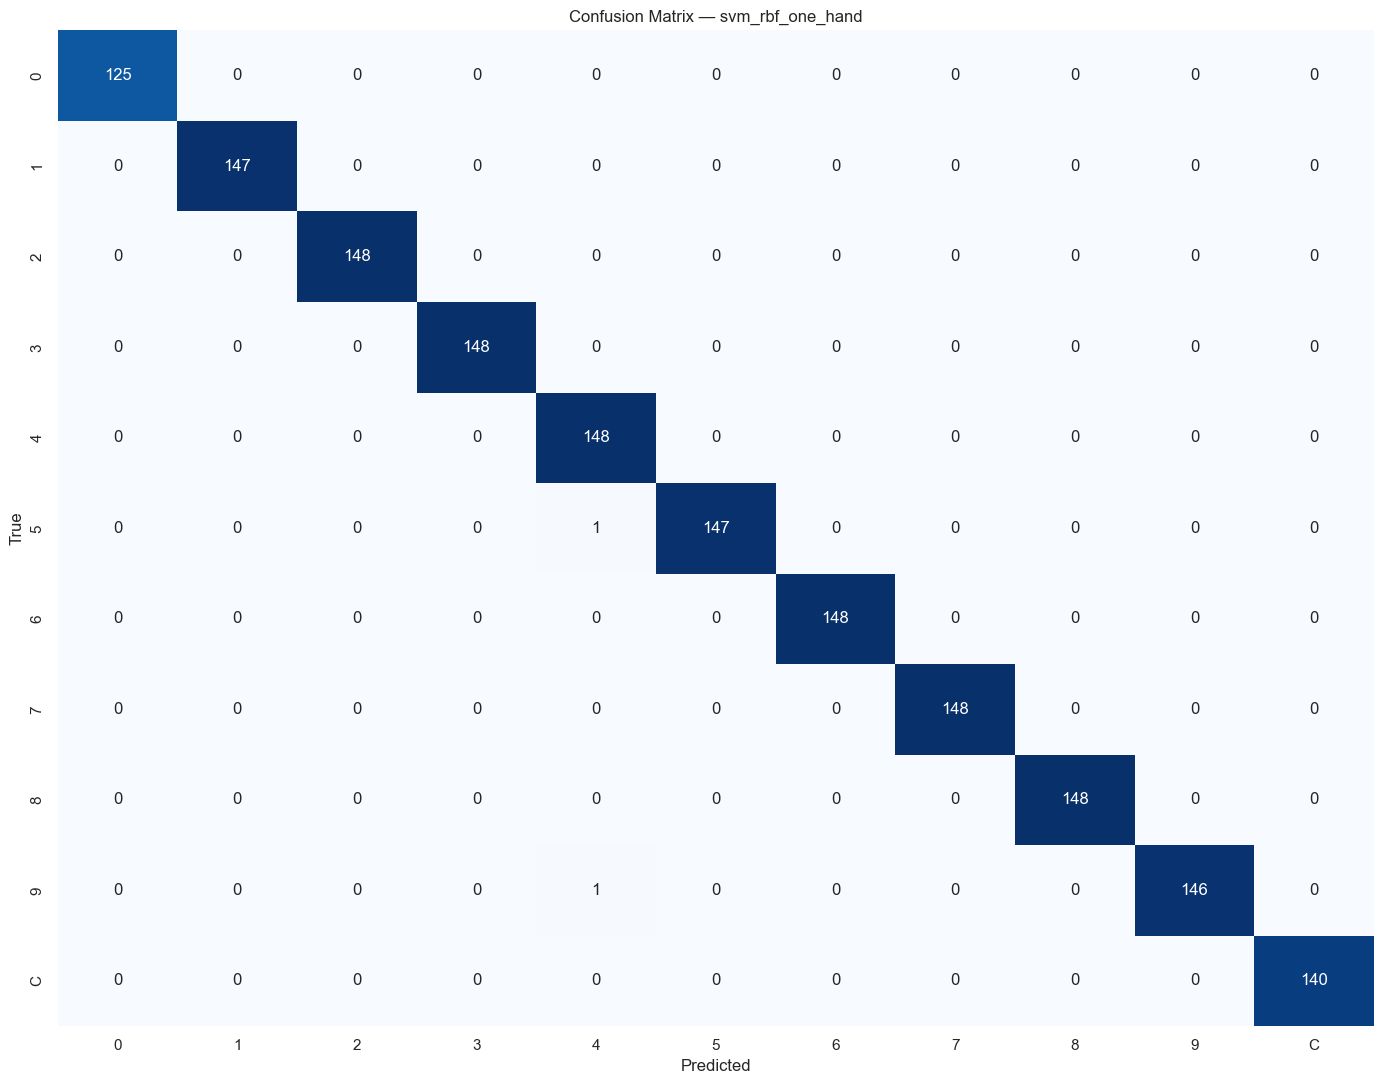


Classification report — svm_rbf_one_hand
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000       125
           1     1.0000    1.0000    1.0000       147
           2     1.0000    1.0000    1.0000       148
           3     1.0000    1.0000    1.0000       148
           4     0.9867    1.0000    0.9933       148
           5     1.0000    0.9932    0.9966       148
           6     1.0000    1.0000    1.0000       148
           7     1.0000    1.0000    1.0000       148
           8     1.0000    1.0000    1.0000       148
           9     1.0000    0.9932    0.9966       147
           C     1.0000    1.0000    1.0000       140

    accuracy                         0.9987      1595
   macro avg     0.9988    0.9988    0.9988      1595
weighted avg     0.9988    0.9987    0.9987      1595

Saved classification report: C:\Users\singh\Desktop\a2 i&v\edited code files\outputs\classification_report_svm_rbf_one_hand.txt
Saved confusion m

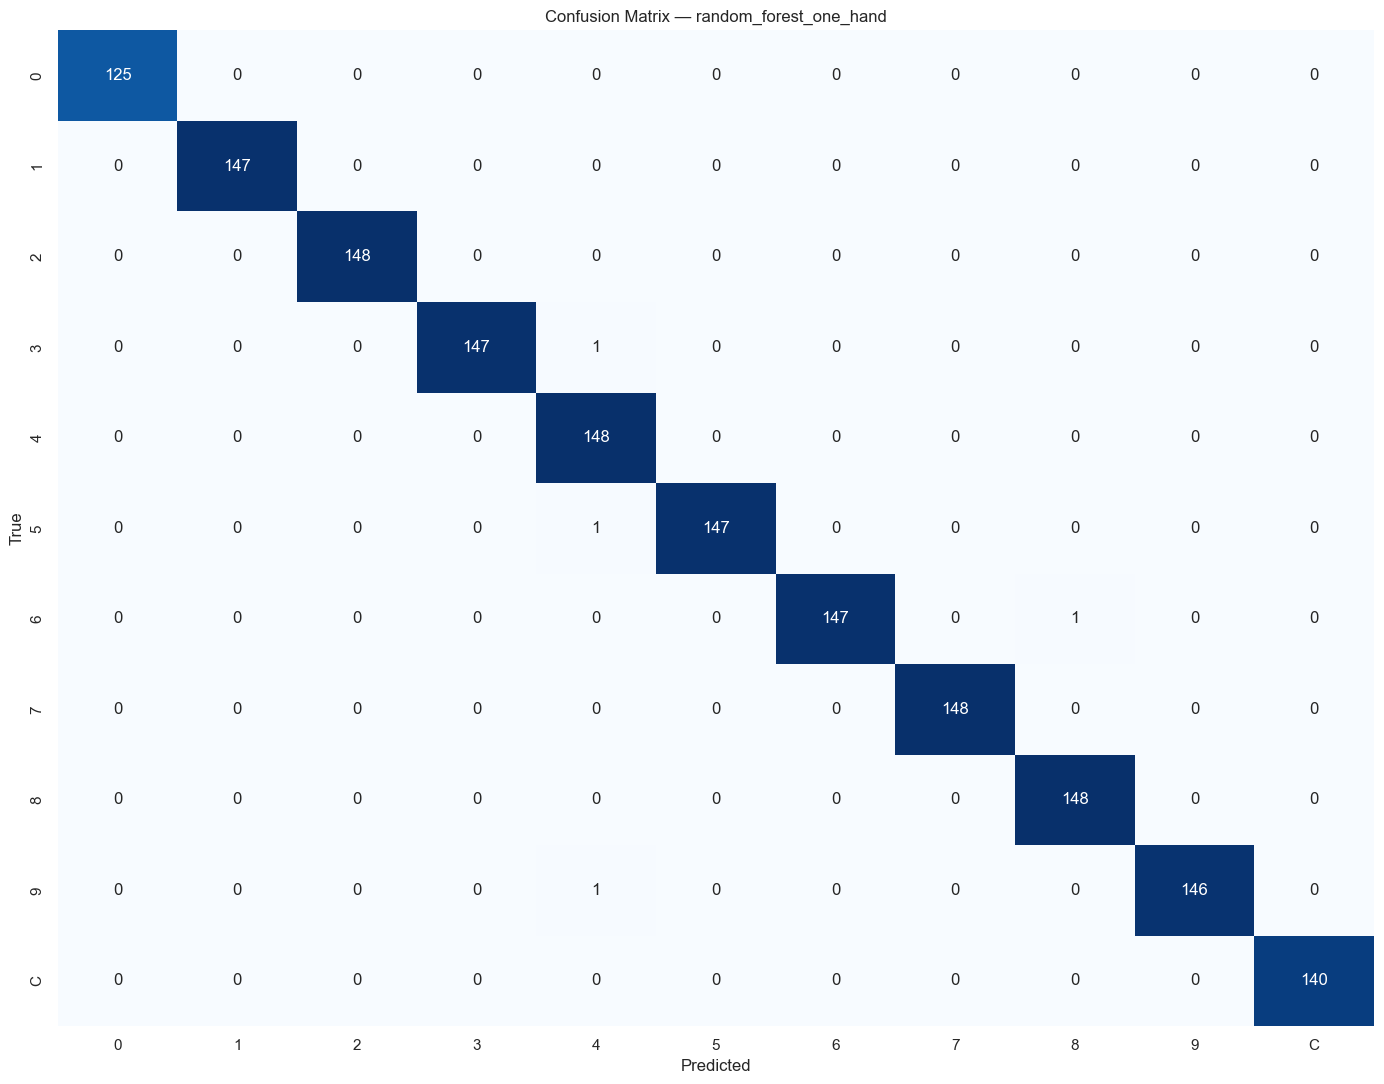


Classification report — random_forest_one_hand
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000       125
           1     1.0000    1.0000    1.0000       147
           2     1.0000    1.0000    1.0000       148
           3     1.0000    0.9932    0.9966       148
           4     0.9801    1.0000    0.9900       148
           5     1.0000    0.9932    0.9966       148
           6     1.0000    0.9932    0.9966       148
           7     1.0000    1.0000    1.0000       148
           8     0.9933    1.0000    0.9966       148
           9     1.0000    0.9932    0.9966       147
           C     1.0000    1.0000    1.0000       140

    accuracy                         0.9975      1595
   macro avg     0.9976    0.9975    0.9975      1595
weighted avg     0.9975    0.9975    0.9975      1595

Saved classification report: C:\Users\singh\Desktop\a2 i&v\edited code files\outputs\classification_report_random_forest_one_hand.txt
Saved

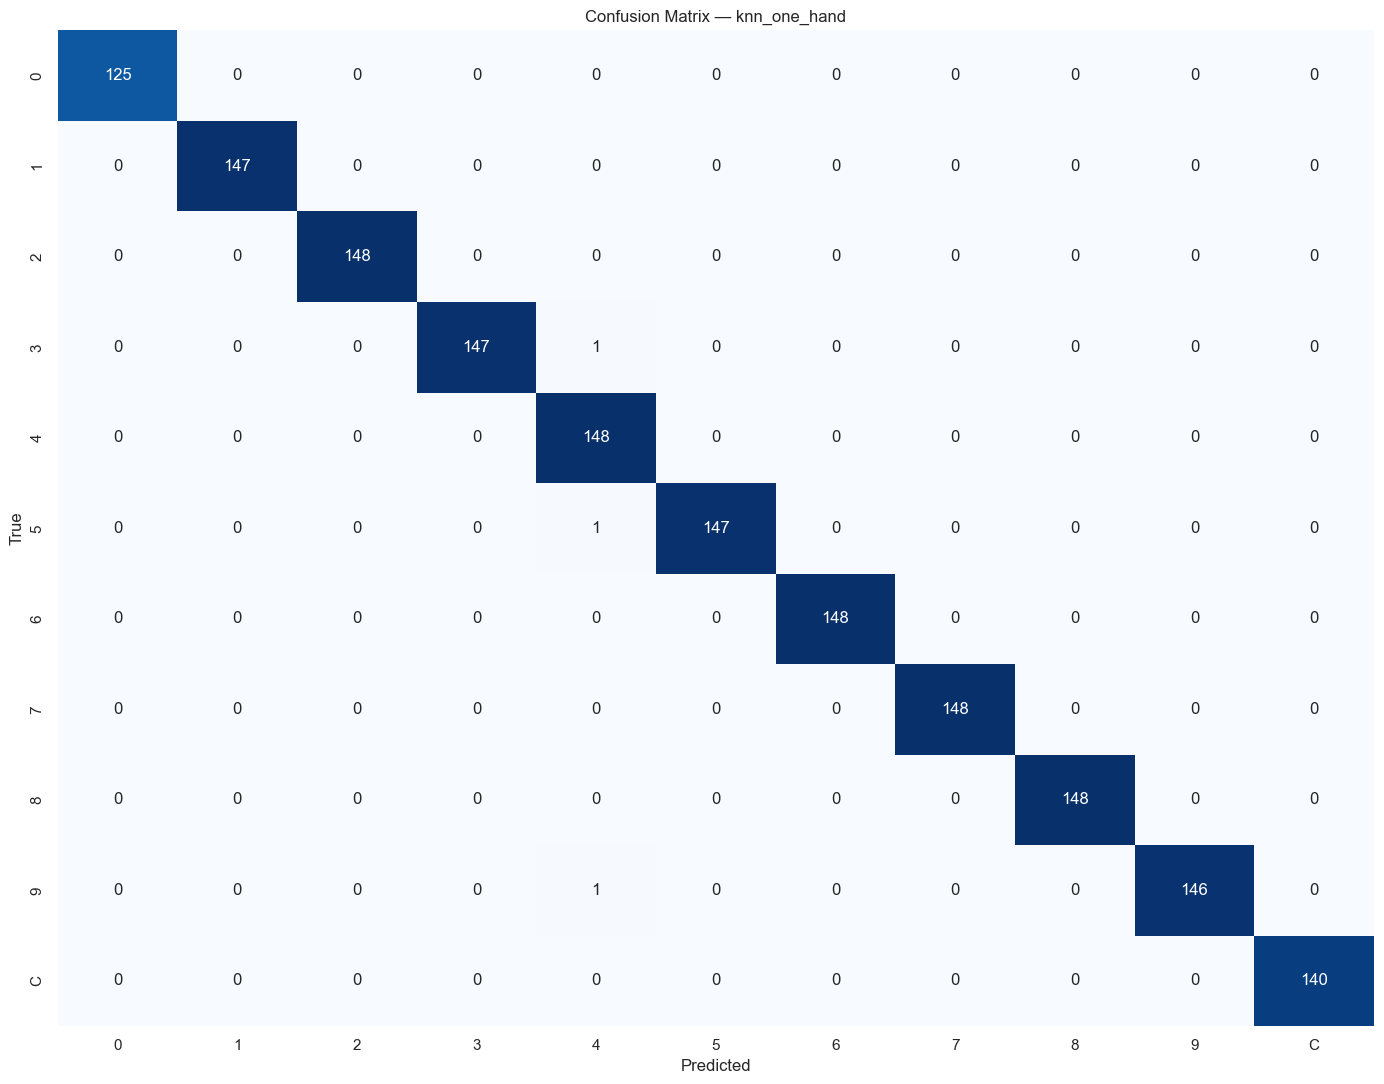


Classification report — knn_one_hand
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000       125
           1     1.0000    1.0000    1.0000       147
           2     1.0000    1.0000    1.0000       148
           3     1.0000    0.9932    0.9966       148
           4     0.9801    1.0000    0.9900       148
           5     1.0000    0.9932    0.9966       148
           6     1.0000    1.0000    1.0000       148
           7     1.0000    1.0000    1.0000       148
           8     1.0000    1.0000    1.0000       148
           9     1.0000    0.9932    0.9966       147
           C     1.0000    1.0000    1.0000       140

    accuracy                         0.9981      1595
   macro avg     0.9982    0.9982    0.9982      1595
weighted avg     0.9982    0.9981    0.9981      1595

Saved classification report: C:\Users\singh\Desktop\a2 i&v\edited code files\outputs\classification_report_knn_one_hand.txt
Saved confusion matrix: C

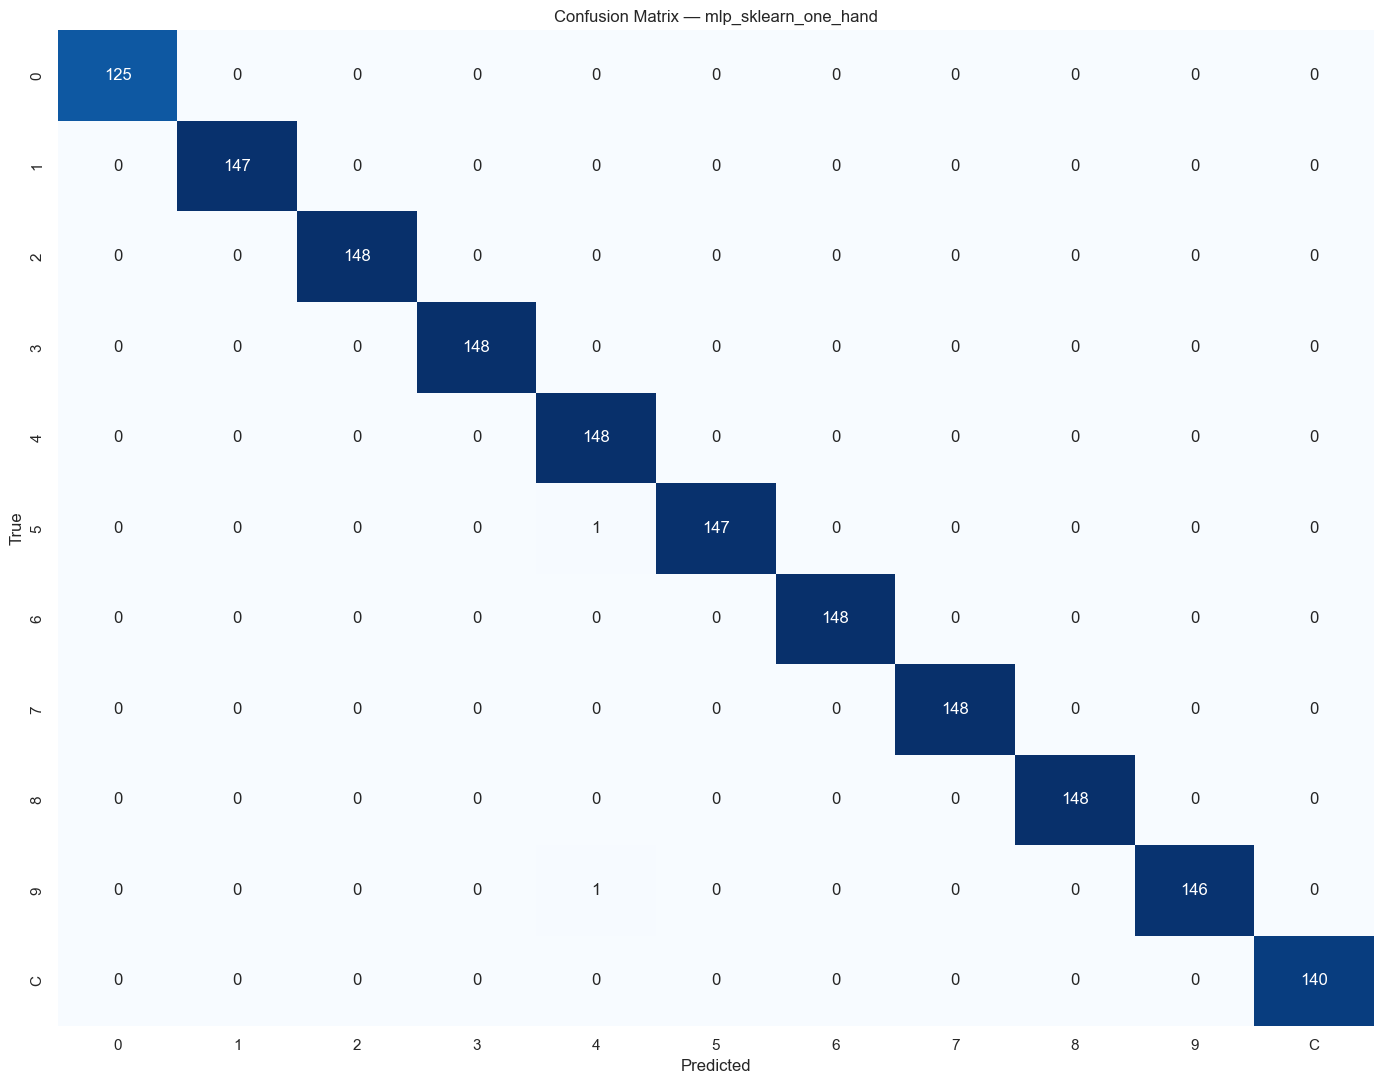


Classification report — mlp_sklearn_one_hand
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000       125
           1     1.0000    1.0000    1.0000       147
           2     1.0000    1.0000    1.0000       148
           3     1.0000    1.0000    1.0000       148
           4     0.9867    1.0000    0.9933       148
           5     1.0000    0.9932    0.9966       148
           6     1.0000    1.0000    1.0000       148
           7     1.0000    1.0000    1.0000       148
           8     1.0000    1.0000    1.0000       148
           9     1.0000    0.9932    0.9966       147
           C     1.0000    1.0000    1.0000       140

    accuracy                         0.9987      1595
   macro avg     0.9988    0.9988    0.9988      1595
weighted avg     0.9988    0.9987    0.9987      1595

Saved classification report: C:\Users\singh\Desktop\a2 i&v\edited code files\outputs\classification_report_mlp_sklearn_one_hand.txt
Saved con

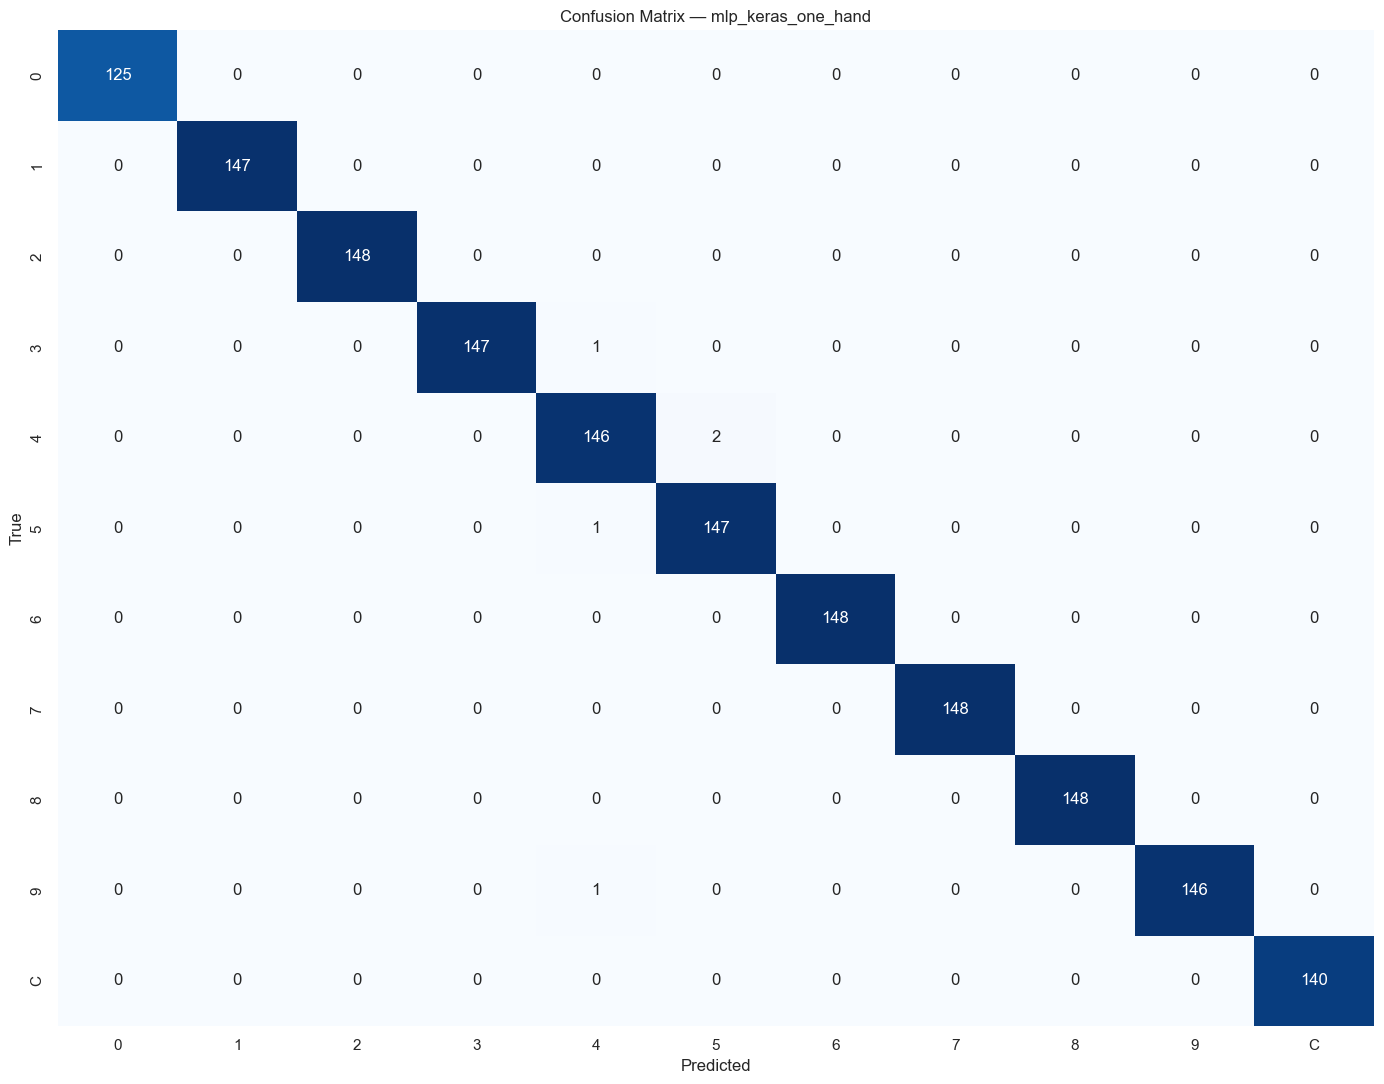


Classification report — mlp_keras_one_hand
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000       125
           1     1.0000    1.0000    1.0000       147
           2     1.0000    1.0000    1.0000       148
           3     1.0000    0.9932    0.9966       148
           4     0.9799    0.9865    0.9832       148
           5     0.9866    0.9932    0.9899       148
           6     1.0000    1.0000    1.0000       148
           7     1.0000    1.0000    1.0000       148
           8     1.0000    1.0000    1.0000       148
           9     1.0000    0.9932    0.9966       147
           C     1.0000    1.0000    1.0000       140

    accuracy                         0.9969      1595
   macro avg     0.9969    0.9969    0.9969      1595
weighted avg     0.9969    0.9969    0.9969      1595

Saved classification report: C:\Users\singh\Desktop\a2 i&v\edited code files\outputs\classification_report_mlp_keras_one_hand.txt
Saved Keras t

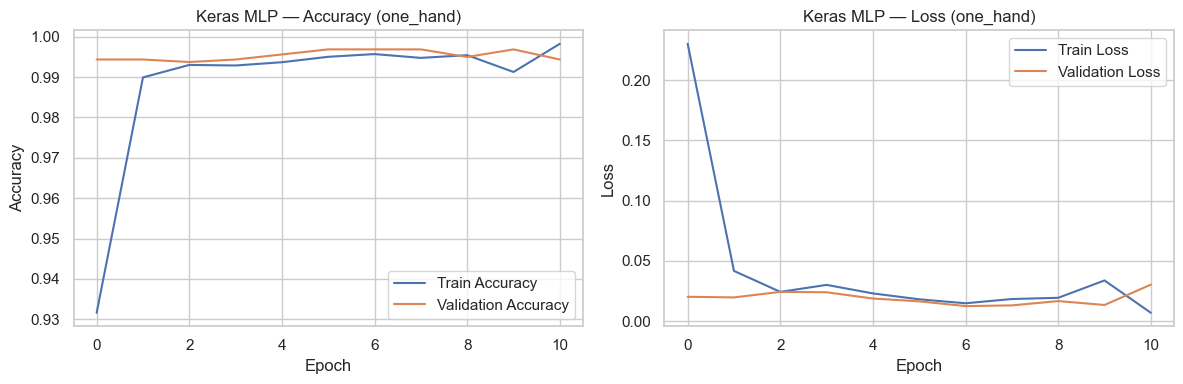


=== Evaluating models for two_hand ===

Evaluating svm_rbf_two_hand...

Evaluating random_forest_two_hand...

Evaluating knn_two_hand...

Evaluating mlp_sklearn_two_hand...

Evaluating mlp_keras_two_hand...

=== Model Comparison — two_hand ===


,hand_group,model,accuracy,weighted_f1
0,two_hand,svm_rbf,0.998431,0.998431
1,two_hand,random_forest,0.998038,0.998037
2,two_hand,knn,0.996862,0.996860
3,two_hand,mlp_sklearn,0.996469,0.996465
4,two_hand,mlp_keras,0.985092,0.984979


Saved confusion matrix: C:\Users\singh\Desktop\a2 i&v\edited code files\outputs\confusion_matrix_svm_rbf_two_hand.png


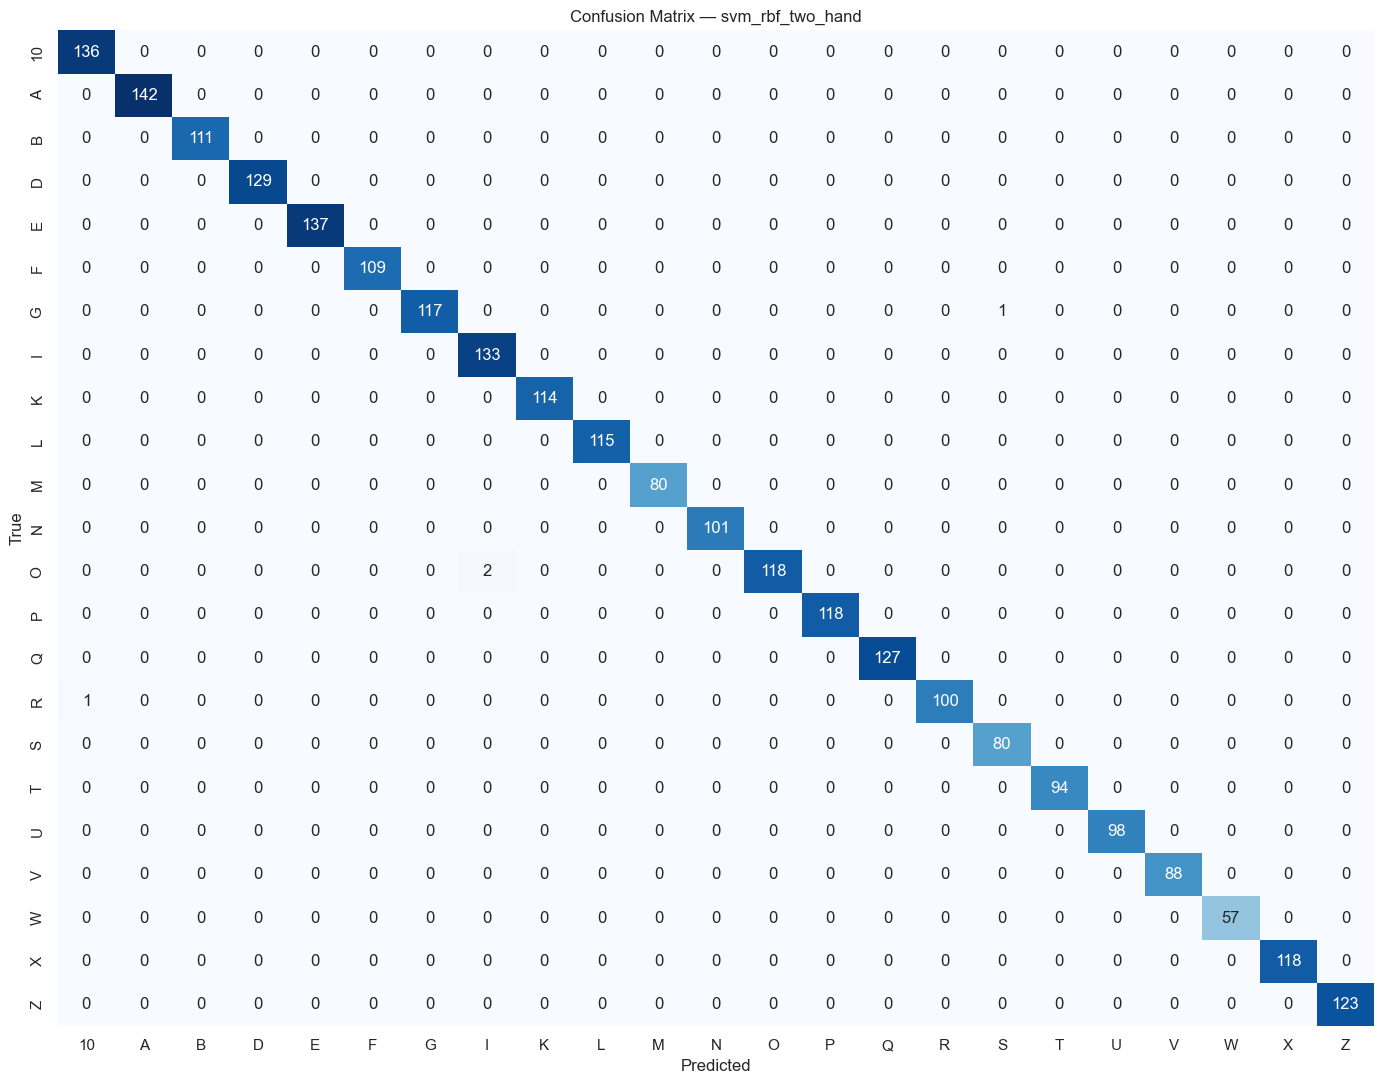


Classification report — svm_rbf_two_hand
              precision    recall  f1-score   support

          10     0.9927    1.0000    0.9963       136
           A     1.0000    1.0000    1.0000       142
           B     1.0000    1.0000    1.0000       111
           D     1.0000    1.0000    1.0000       129
           E     1.0000    1.0000    1.0000       137
           F     1.0000    1.0000    1.0000       109
           G     1.0000    0.9915    0.9957       118
           I     0.9852    1.0000    0.9925       133
           K     1.0000    1.0000    1.0000       114
           L     1.0000    1.0000    1.0000       115
           M     1.0000    1.0000    1.0000        80
           N     1.0000    1.0000    1.0000       101
           O     1.0000    0.9833    0.9916       120
           P     1.0000    1.0000    1.0000       118
           Q     1.0000    1.0000    1.0000       127
           R     1.0000    0.9901    0.9950       101
           S     0.9877    1.0000    0.

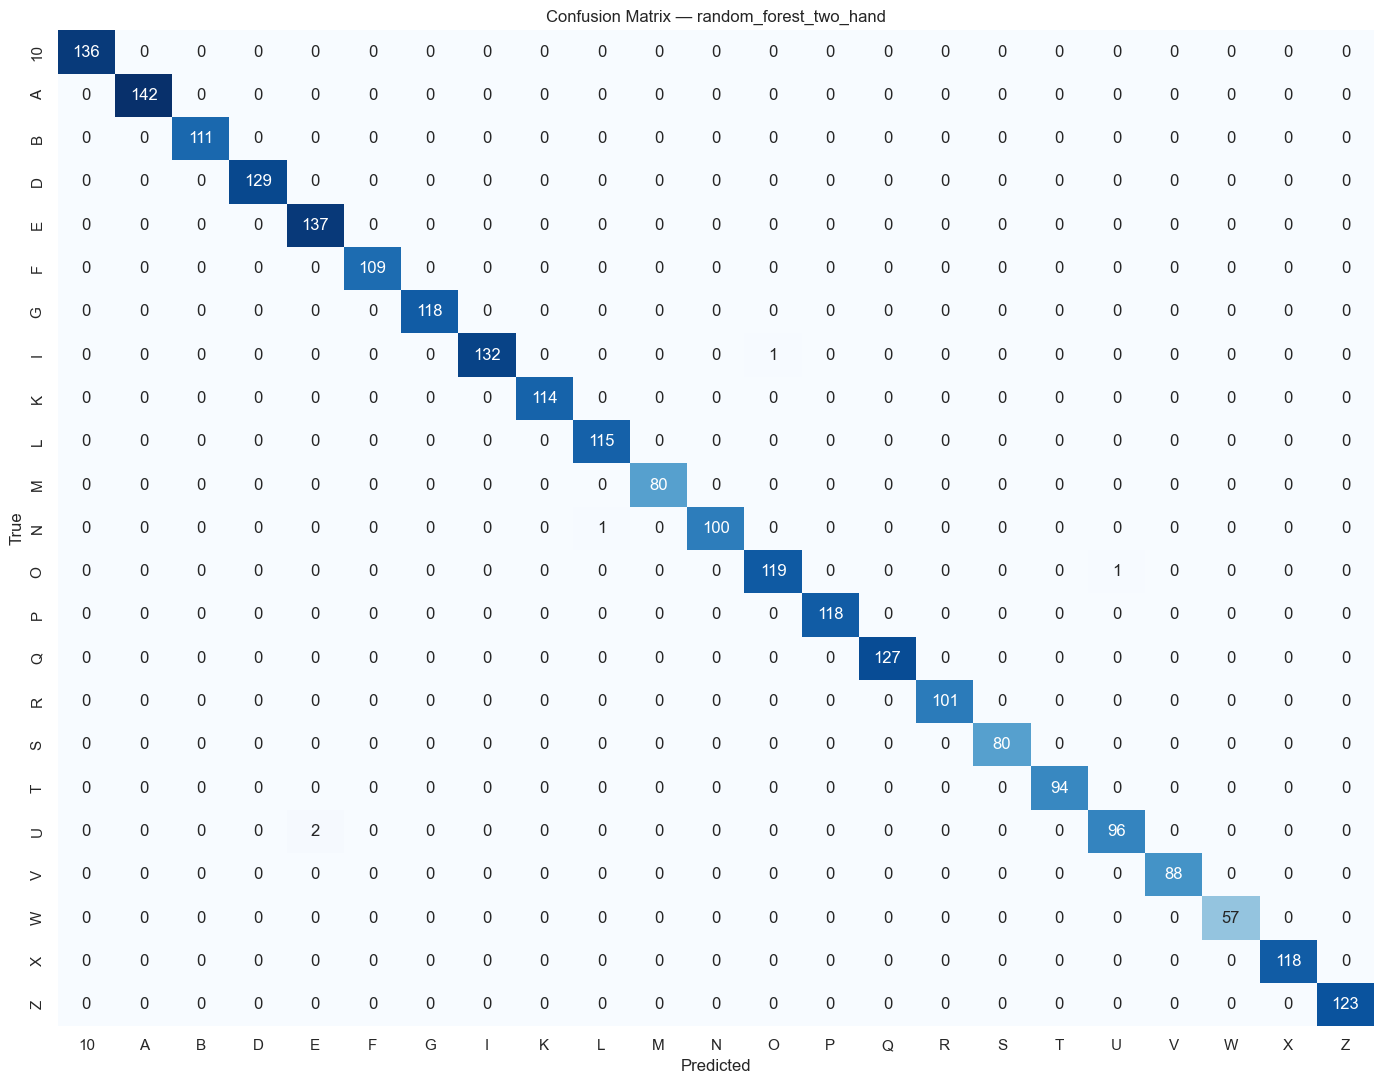


Classification report — random_forest_two_hand
              precision    recall  f1-score   support

          10     1.0000    1.0000    1.0000       136
           A     1.0000    1.0000    1.0000       142
           B     1.0000    1.0000    1.0000       111
           D     1.0000    1.0000    1.0000       129
           E     0.9856    1.0000    0.9928       137
           F     1.0000    1.0000    1.0000       109
           G     1.0000    1.0000    1.0000       118
           I     1.0000    0.9925    0.9962       133
           K     1.0000    1.0000    1.0000       114
           L     0.9914    1.0000    0.9957       115
           M     1.0000    1.0000    1.0000        80
           N     1.0000    0.9901    0.9950       101
           O     0.9917    0.9917    0.9917       120
           P     1.0000    1.0000    1.0000       118
           Q     1.0000    1.0000    1.0000       127
           R     1.0000    1.0000    1.0000       101
           S     1.0000    1.0000

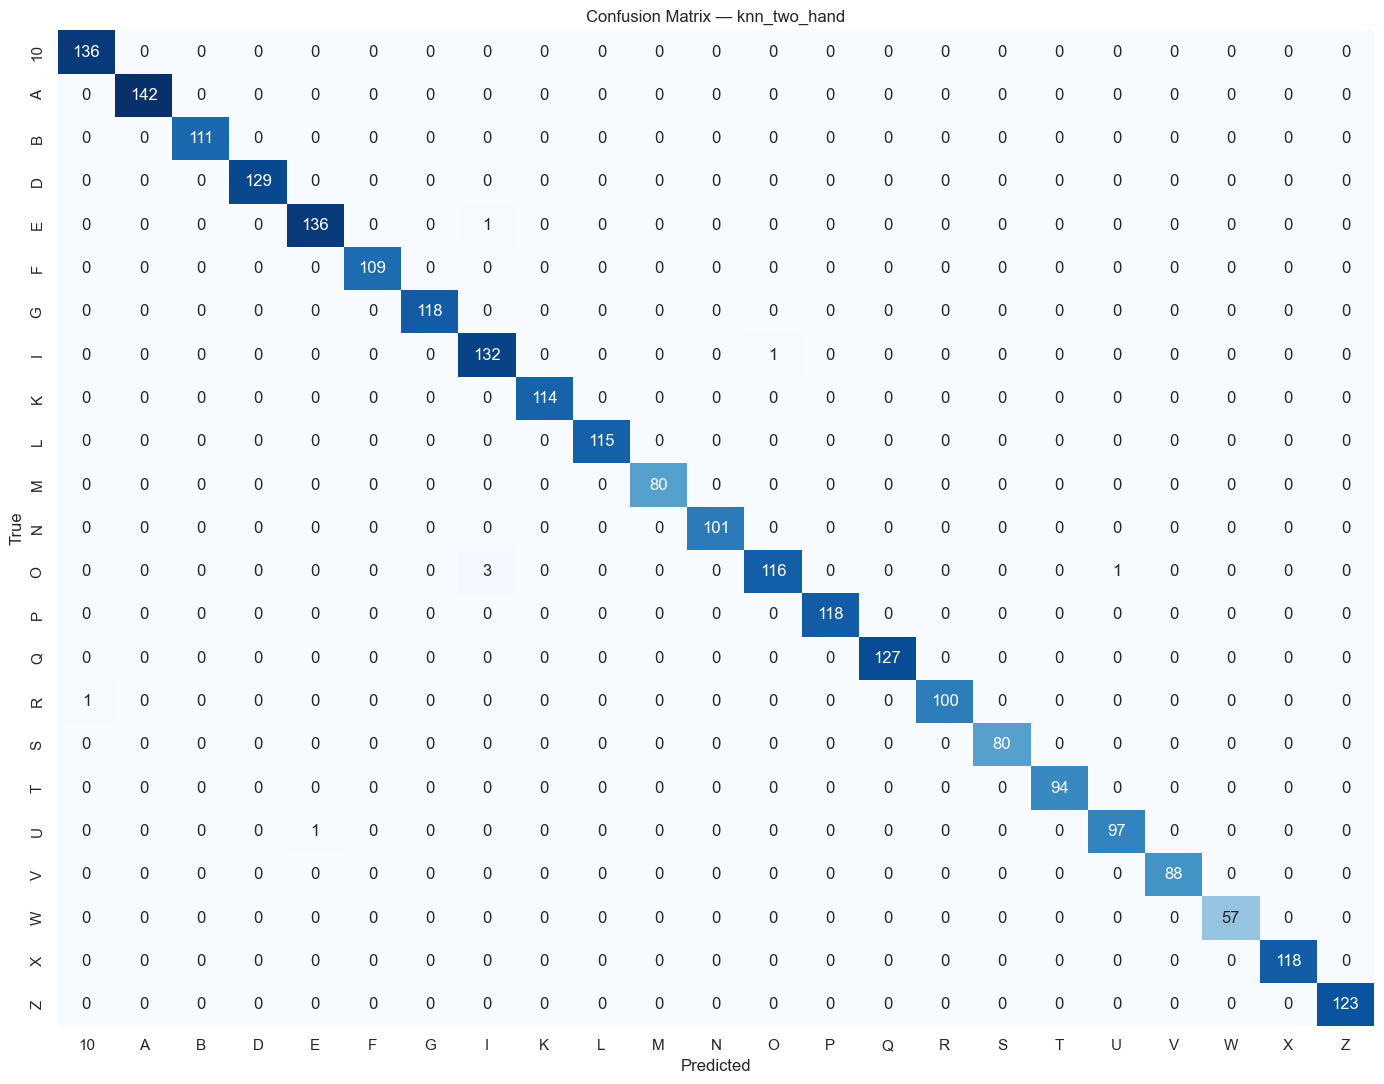


Classification report — knn_two_hand
              precision    recall  f1-score   support

          10     0.9927    1.0000    0.9963       136
           A     1.0000    1.0000    1.0000       142
           B     1.0000    1.0000    1.0000       111
           D     1.0000    1.0000    1.0000       129
           E     0.9927    0.9927    0.9927       137
           F     1.0000    1.0000    1.0000       109
           G     1.0000    1.0000    1.0000       118
           I     0.9706    0.9925    0.9814       133
           K     1.0000    1.0000    1.0000       114
           L     1.0000    1.0000    1.0000       115
           M     1.0000    1.0000    1.0000        80
           N     1.0000    1.0000    1.0000       101
           O     0.9915    0.9667    0.9789       120
           P     1.0000    1.0000    1.0000       118
           Q     1.0000    1.0000    1.0000       127
           R     1.0000    0.9901    0.9950       101
           S     1.0000    1.0000    1.0000

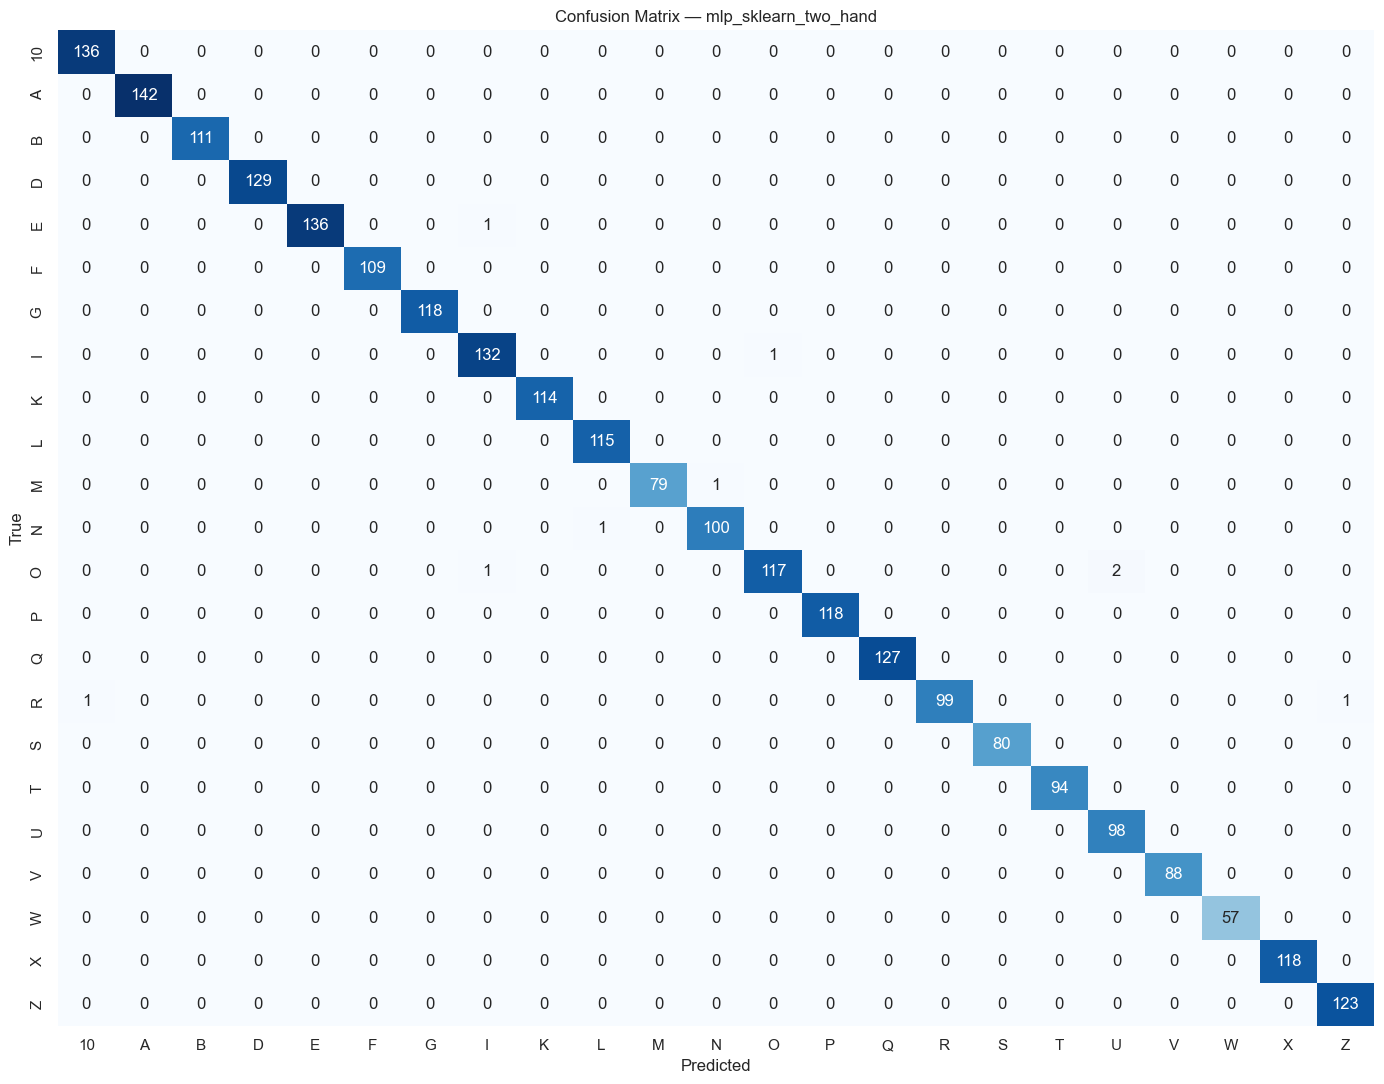


Classification report — mlp_sklearn_two_hand
              precision    recall  f1-score   support

          10     0.9927    1.0000    0.9963       136
           A     1.0000    1.0000    1.0000       142
           B     1.0000    1.0000    1.0000       111
           D     1.0000    1.0000    1.0000       129
           E     1.0000    0.9927    0.9963       137
           F     1.0000    1.0000    1.0000       109
           G     1.0000    1.0000    1.0000       118
           I     0.9851    0.9925    0.9888       133
           K     1.0000    1.0000    1.0000       114
           L     0.9914    1.0000    0.9957       115
           M     1.0000    0.9875    0.9937        80
           N     0.9901    0.9901    0.9901       101
           O     0.9915    0.9750    0.9832       120
           P     1.0000    1.0000    1.0000       118
           Q     1.0000    1.0000    1.0000       127
           R     1.0000    0.9802    0.9900       101
           S     1.0000    1.0000  

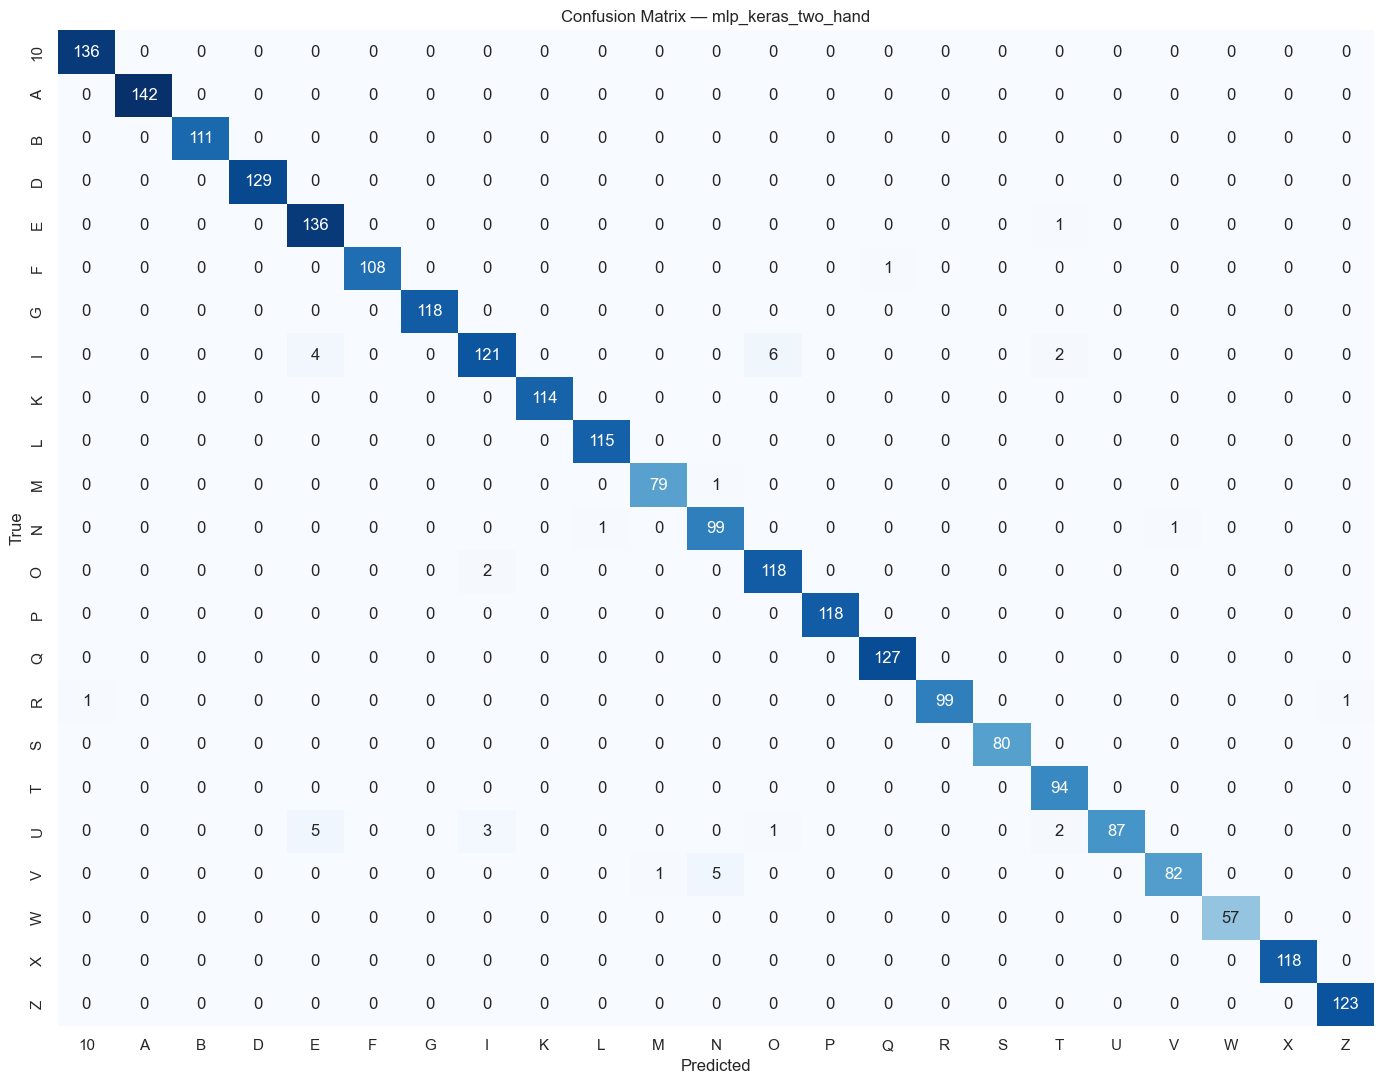


Classification report — mlp_keras_two_hand
              precision    recall  f1-score   support

          10     0.9927    1.0000    0.9963       136
           A     1.0000    1.0000    1.0000       142
           B     1.0000    1.0000    1.0000       111
           D     1.0000    1.0000    1.0000       129
           E     0.9379    0.9927    0.9645       137
           F     1.0000    0.9908    0.9954       109
           G     1.0000    1.0000    1.0000       118
           I     0.9603    0.9098    0.9344       133
           K     1.0000    1.0000    1.0000       114
           L     0.9914    1.0000    0.9957       115
           M     0.9875    0.9875    0.9875        80
           N     0.9429    0.9802    0.9612       101
           O     0.9440    0.9833    0.9633       120
           P     1.0000    1.0000    1.0000       118
           Q     0.9922    1.0000    0.9961       127
           R     1.0000    0.9802    0.9900       101
           S     1.0000    1.0000    

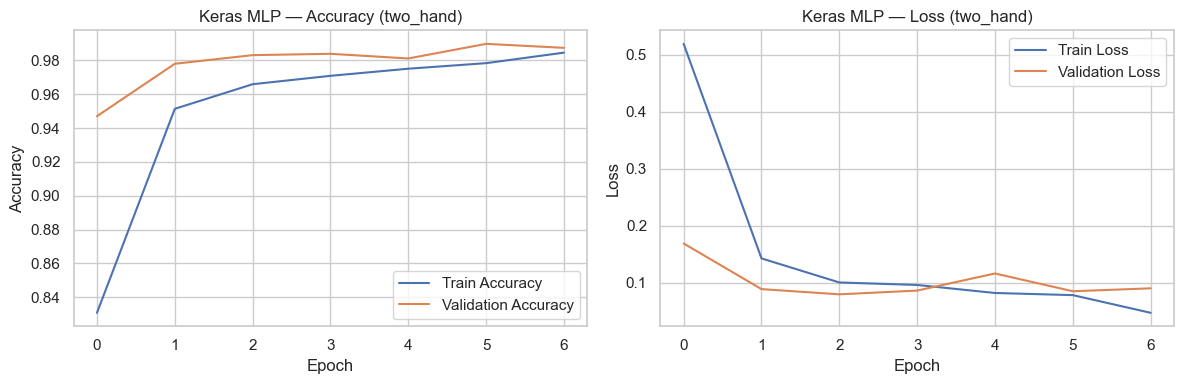


=== Final Routed Model Comparison ===


,hand_group,model,accuracy,weighted_f1
0,one_hand,svm_rbf,0.998746,0.998748
1,one_hand,mlp_sklearn,0.998746,0.998748
2,one_hand,knn,0.998119,0.998125
3,one_hand,random_forest,0.997492,0.997498
4,one_hand,mlp_keras,0.996865,0.996872
5,two_hand,svm_rbf,0.998431,0.998431
6,two_hand,random_forest,0.998038,0.998037
7,two_hand,knn,0.996862,0.996860
8,two_hand,mlp_sklearn,0.996469,0.996465
9,two_hand,mlp_keras,0.985092,0.984979


Saved one-hand results: C:\Users\singh\Desktop\a2 i&v\edited code files\outputs\one_hand_model_results.csv
Saved two-hand results: C:\Users\singh\Desktop\a2 i&v\edited code files\outputs\two_hand_model_results.csv
Saved combined routed results: C:\Users\singh\Desktop\a2 i&v\edited code files\outputs\one_hand_two_hand_model_results.csv


In [19]:
#changes: Evaluate sklearn + Keras models separately for one-hand and two-hand routed setup.
#added: Save separate confusion matrices, classification reports, and Keras training curves.

def evaluate_group_models(group):
    print(f"\n=== Evaluating models for {group['name']} ===")

    labels_sorted = sorted(np.unique(group["y_test"]))
    label_names = group["label_encoder"].inverse_transform(labels_sorted)

    results = []
    predictions = {}

    # ── Sklearn classifiers ──────────────────────────────────────────────────
    for model_name, clf in group["models"].items():
        print(f"\nEvaluating {model_name}_{group['name']}...")

        pred = clf.predict(group["X_test"])
        predictions[model_name] = pred

        acc = accuracy_score(group["y_test"], pred)
        f1 = f1_score(group["y_test"], pred, average="weighted")

        results.append({
            "hand_group": group["name"],
            "model": model_name,
            "accuracy": acc,
            "weighted_f1": f1
        })

    # ── Keras MLP ────────────────────────────────────────────────────────────
    print(f"\nEvaluating mlp_keras_{group['name']}...")

    keras_pred = np.argmax(group["keras_model"].predict(group["X_test_keras"], verbose=0), axis=1)
    predictions["mlp_keras"] = keras_pred

    keras_acc = accuracy_score(group["y_test"], keras_pred)
    keras_f1 = f1_score(group["y_test"], keras_pred, average="weighted")

    results.append({
        "hand_group": group["name"],
        "model": "mlp_keras",
        "accuracy": keras_acc,
        "weighted_f1": keras_f1
    })

    # ── Result table ─────────────────────────────────────────────────────────
    df_group_results = (
        pd.DataFrame(results)
        .sort_values("weighted_f1", ascending=False)
        .reset_index(drop=True)
    )

    print(f"\n=== Model Comparison — {group['name']} ===")
    display(df_group_results)

    # ── Confusion matrices and classification reports ────────────────────────
    for model_name, pred in predictions.items():
        routed_name = f"{model_name}_{group['name']}"

        cm = confusion_matrix(group["y_test"], pred, labels=labels_sorted)

        plt.figure(figsize=(14, 11))
        sns.heatmap(
            cm,
            annot=True,
            fmt="d",
            cmap="Blues",
            xticklabels=label_names,
            yticklabels=label_names,
            cbar=False
        )
        plt.title(f"Confusion Matrix — {routed_name}")
        plt.xlabel("Predicted")
        plt.ylabel("True")
        plt.tight_layout()

        cm_path = FIGURES_DIR / f"confusion_matrix_{routed_name}.png"
        plt.savefig(cm_path, dpi=300, bbox_inches="tight")
        print(f"Saved confusion matrix: {cm_path}")

        plt.show()

        print(f"\nClassification report — {routed_name}")
        report_text = classification_report(
            group["y_test"],
            pred,
            target_names=label_names,
            digits=4
        )
        print(report_text)

        report_path = RESULTS_DIR / f"classification_report_{routed_name}.txt"
        with open(report_path, "w", encoding="utf-8") as f:
            f.write(report_text)

        print(f"Saved classification report: {report_path}")

    # ── Keras training curves ────────────────────────────────────────────────
    history = group["keras_history"]

    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(history.history["accuracy"], label="Train Accuracy")
    plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
    plt.title(f"Keras MLP — Accuracy ({group['name']})")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history.history["loss"], label="Train Loss")
    plt.plot(history.history["val_loss"], label="Validation Loss")
    plt.title(f"Keras MLP — Loss ({group['name']})")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()

    plt.tight_layout()

    hist_path = FIGURES_DIR / f"training_history_keras_{group['name']}.png"
    plt.savefig(hist_path, dpi=300, bbox_inches="tight")
    print(f"Saved Keras training history: {hist_path}")

    plt.show()

    group["predictions"] = predictions
    group["results_df"] = df_group_results

    return group


one_hand_data = evaluate_group_models(one_hand_data)
two_hand_data = evaluate_group_models(two_hand_data)

# ── Combined final result table ───────────────────────────────────────────────
df_results = (
    pd.concat(
        [one_hand_data["results_df"], two_hand_data["results_df"]],
        ignore_index=True
    )
    .sort_values(["hand_group", "weighted_f1"], ascending=[True, False])
    .reset_index(drop=True)
)

print("\n=== Final Routed Model Comparison ===")
display(df_results)

#added: Save final routed model comparison table for report/presentation.
df_results.to_csv(ROUTED_RESULTS_CSV, index=False)

one_hand_data["results_df"].to_csv(ONE_HAND_RESULTS_CSV, index=False)
two_hand_data["results_df"].to_csv(TWO_HAND_RESULTS_CSV, index=False)

print(f"Saved one-hand results: {ONE_HAND_RESULTS_CSV}")
print(f"Saved two-hand results: {TWO_HAND_RESULTS_CSV}")
print(f"Saved combined routed results: {ROUTED_RESULTS_CSV}")

## Hard-Pair Analysis

This section analyses selected hard-pair confusions observed during live webcam testing. The focus is on the pairs `L/A`, `T/A`, `U/S`, and `U/E`, because these pairs showed incorrect or unstable predictions during manual checking.

Random Forest feature importance is used to identify which keypoint features contribute most to classification. The hard-pair analysis then checks whether the selected pairs also show confusion in the held-out test data.

For each selected pair, the analysis reports:

- pair accuracy,
- number of test samples,
- directional confusion such as `L → A`,
- correct predictions for each sign in the pair.

This helps explain whether live prediction errors are related to similar keypoint patterns between signs.


=== Random Forest Feature Analysis — one_hand ===


,feature,importance
0,left_rel_y_12,0.016498
1,left_pair_3_18,0.015277
2,left_pair_0_12,0.014855
3,left_pair_0_16,0.013442
4,left_pair_0_8,0.013134
5,left_rel_y_4,0.012060
6,left_pair_8_16,0.011346
7,left_pair_1_16,0.011225
8,left_pair_8_20,0.011059
9,left_pair_12_20,0.010966


Saved feature-importance plot: C:\Users\singh\Desktop\a2 i&v\edited code files\outputs\rf_feature_importance_one_hand.png


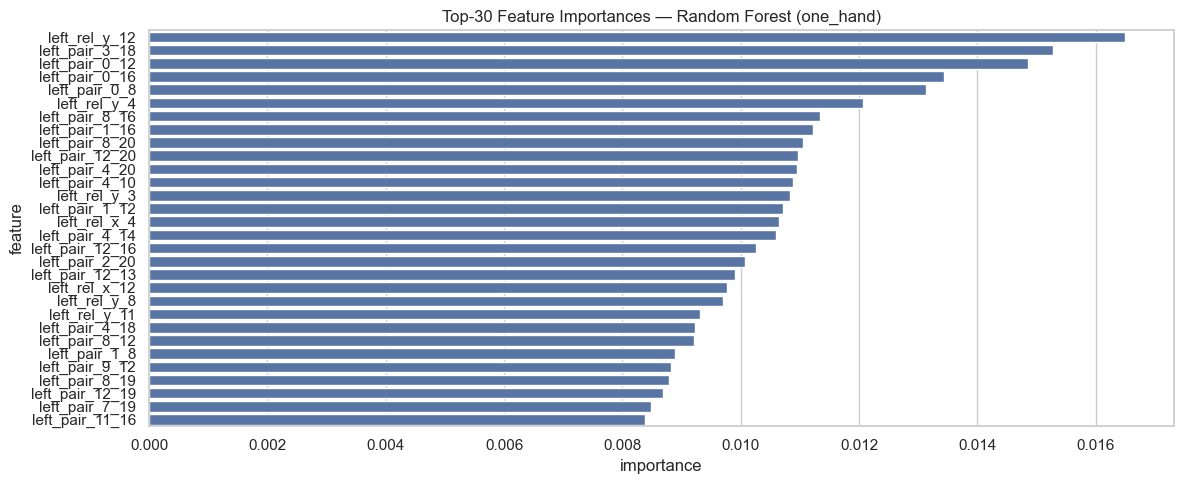

Saved feature-importance table: C:\Users\singh\Desktop\a2 i&v\edited code files\outputs\rf_feature_importance_one_hand.csv

Hard-pair accuracy — Random Forest (one_hand):
  L/A: skipped — pair not present in one_hand classes
  T/A: skipped — pair not present in one_hand classes
  U/S: skipped — pair not present in one_hand classes
  U/E: skipped — pair not present in one_hand classes

=== Random Forest Feature Analysis — two_hand ===


,feature,importance
0,left_rel_y_10,0.014667
1,left_rel_y_11,0.014474
2,left_rel_x_1,0.009071
3,left_rel_y_12,0.008773
4,left_rel_x_2,0.008619
5,left_rel_y_16,0.008574
6,right_rel_y_15,0.008540
7,left_rel_y_8,0.008516
8,left_pair_12_16,0.008075
9,left_rel_y_5,0.007767


Saved feature-importance plot: C:\Users\singh\Desktop\a2 i&v\edited code files\outputs\rf_feature_importance_two_hand.png


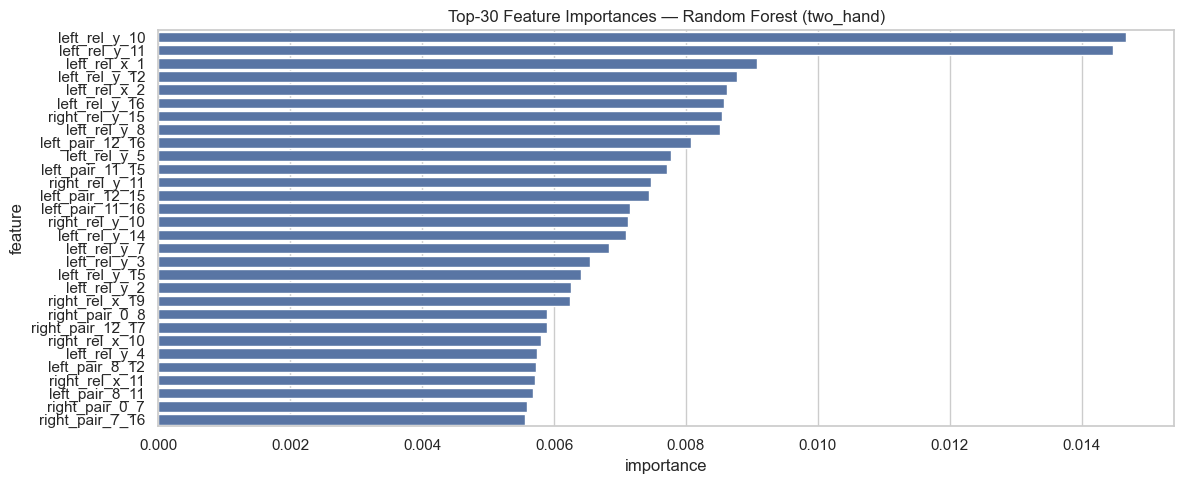

Saved feature-importance table: C:\Users\singh\Desktop\a2 i&v\edited code files\outputs\rf_feature_importance_two_hand.csv

Hard-pair accuracy — Random Forest (two_hand):
  L/A: 1.0000  (257 samples)
      L → A: 0
      A → L: 0
      correct L: 115
      correct A: 142
  T/A: 1.0000  (236 samples)
      T → A: 0
      A → T: 0
      correct T: 94
      correct A: 142
  U/S: 0.9888  (178 samples)
      U → S: 0
      S → U: 0
      correct U: 96
      correct S: 80
  U/E: 0.9915  (235 samples)
      U → E: 2
      E → U: 0
      correct U: 96
      correct E: 137


,hand_group,pair,accuracy,test_samples,L_to_A,A_to_L,correct_L,correct_A,basis,T_to_A,A_to_T,correct_T,U_to_S,S_to_U,correct_U,correct_S,U_to_E,E_to_U,correct_E
0,two_hand,L/A,1.000000,257,0.0,0.0,115.0,142.0,manual live-testing confusion pair,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,two_hand,T/A,1.000000,236,NaN,NaN,NaN,142.0,manual live-testing confusion pair,0.0,0.0,94.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,two_hand,U/S,0.988764,178,NaN,NaN,NaN,NaN,manual live-testing confusion pair,NaN,NaN,NaN,0.0,0.0,96.0,80.0,NaN,NaN,NaN
3,two_hand,U/E,0.991489,235,NaN,NaN,NaN,NaN,manual live-testing confusion pair,NaN,NaN,NaN,NaN,NaN,96.0,NaN,2.0,0.0,137.0


Saved hard-pair analysis: C:\Users\singh\Desktop\a2 i&v\edited code files\outputs\hard_pair_analysis_two_hand.csv


In [20]:
#changes: Run Random Forest feature-importance and hard-pair analysis separately
# for one-hand and two-hand routed datasets.
# The hard-pair list is now based on observed live webcam confusion pairs:
# L/A, T/A, U/S, U/E.

#changes: Hard-pair list updated using actual manual live-testing observations.
HARD_PAIRS = [('L', 'A'), ('T', 'A'), ('U', 'S'), ('U', 'E')]


def _feature_names():
    """Generate interpretable names for the 508-dim feature vector."""
    names = []

    for hand in ['left', 'right']:
        for lm in range(21):
            names += [f'{hand}_rel_x_{lm}', f'{hand}_rel_y_{lm}']

        for i in range(21):
            for j in range(i + 1, 21):
                names.append(f'{hand}_pair_{i}_{j}')

        names += [f'{hand}_orient_sin', f'{hand}_orient_cos']

    return names


feature_names = _feature_names()


def analyse_random_forest_group(group):
    print(f"\n=== Random Forest Feature Analysis — {group['name']} ===")

    rf = group["models"]["random_forest"]

    df_imp = (
        pd.DataFrame({
            "feature": feature_names,
            "importance": rf.feature_importances_
        })
        .sort_values("importance", ascending=False)
        .reset_index(drop=True)
    )

    display(df_imp.head(TOP_N_FEATURES))

    plt.figure(figsize=(12, 5))
    sns.barplot(
        data=df_imp.head(TOP_N_FEATURES),
        x="importance",
        y="feature",
        orient="h"
    )
    plt.title(f"Top-{TOP_N_FEATURES} Feature Importances — Random Forest ({group['name']})")
    plt.tight_layout()

    imp_path = FIGURES_DIR / f"rf_feature_importance_{group['name']}.png"
    plt.savefig(imp_path, dpi=300, bbox_inches="tight")
    print(f"Saved feature-importance plot: {imp_path}")

    plt.show()

    # Save feature importance table
    imp_csv = RESULTS_DIR / f"rf_feature_importance_{group['name']}.csv"
    df_imp.to_csv(imp_csv, index=False)
    print(f"Saved feature-importance table: {imp_csv}")

    # Hard-pair analysis
    print(f"\nHard-pair accuracy — Random Forest ({group['name']}):")

    y_true_lbl = group["label_encoder"].inverse_transform(group["y_test"])
    y_pred_lbl = group["label_encoder"].inverse_transform(group["predictions"]["random_forest"])

    hard_pair_rows = []

    for a, b in HARD_PAIRS:
        # Skip pairs that are not present in this hand group.
        if a not in group["classes"] or b not in group["classes"]:
            print(f"  {a}/{b}: skipped — pair not present in {group['name']} classes")
            continue

        mask = np.isin(y_true_lbl, [a, b])

        if mask.sum() == 0:
            print(f"  {a}/{b}: no test samples")
            continue

        pair_true = y_true_lbl[mask]
        pair_pred = y_pred_lbl[mask]

        acc = accuracy_score(pair_true, pair_pred)

        #added: Directional confusion counts for observed hard pairs.
        a_to_b = int(((pair_true == a) & (pair_pred == b)).sum())
        b_to_a = int(((pair_true == b) & (pair_pred == a)).sum())
        correct_a = int(((pair_true == a) & (pair_pred == a)).sum())
        correct_b = int(((pair_true == b) & (pair_pred == b)).sum())

        print(f"  {a}/{b}: {acc:.4f}  ({mask.sum()} samples)")
        print(f"      {a} → {b}: {a_to_b}")
        print(f"      {b} → {a}: {b_to_a}")
        print(f"      correct {a}: {correct_a}")
        print(f"      correct {b}: {correct_b}")

        hard_pair_rows.append({
            "hand_group": group["name"],
            "pair": f"{a}/{b}",
            "accuracy": acc,
            "test_samples": int(mask.sum()),
            f"{a}_to_{b}": a_to_b,
            f"{b}_to_{a}": b_to_a,
            f"correct_{a}": correct_a,
            f"correct_{b}": correct_b,
            "basis": "manual live-testing confusion pair"
        })

    df_hard_pairs = pd.DataFrame(hard_pair_rows)

    if not df_hard_pairs.empty:
        display(df_hard_pairs)

        hard_pair_csv = RESULTS_DIR / f"hard_pair_analysis_{group['name']}.csv"
        df_hard_pairs.to_csv(hard_pair_csv, index=False)
        print(f"Saved hard-pair analysis: {hard_pair_csv}")

    group["rf_feature_importance"] = df_imp
    group["hard_pair_results"] = df_hard_pairs

    return group


one_hand_data = analyse_random_forest_group(one_hand_data)
two_hand_data = analyse_random_forest_group(two_hand_data)

---
## Section 12 — Raw-Pixel Baseline Comparison

A privacy-**unsafe** reference model trained on raw grayscale pixels (size and PCA components set in Section 1 config). Used to quantify the accuracy cost of switching to privacy-preserving keypoints.

It uses:

```text
raw grayscale image pixels → resize → flatten → PCA → SVM

Building raw-pixel baseline (64x64 grayscale)...
Raw-pixel samples: 34000
Raw-pixel feature dimensions: 4096
Raw-pixel classes: ['0', '1', '10', '2', '3', '4', '5', '6', '7', '8', '9', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'I', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Z']

Raw-pixel SVM baseline
Accuracy:    0.9633
Weighted F1: 0.9633
Saved raw-pixel confusion matrix: C:\Users\singh\Desktop\a2 i&v\edited code files\outputs\confusion_matrix_pixel_svm_baseline.png


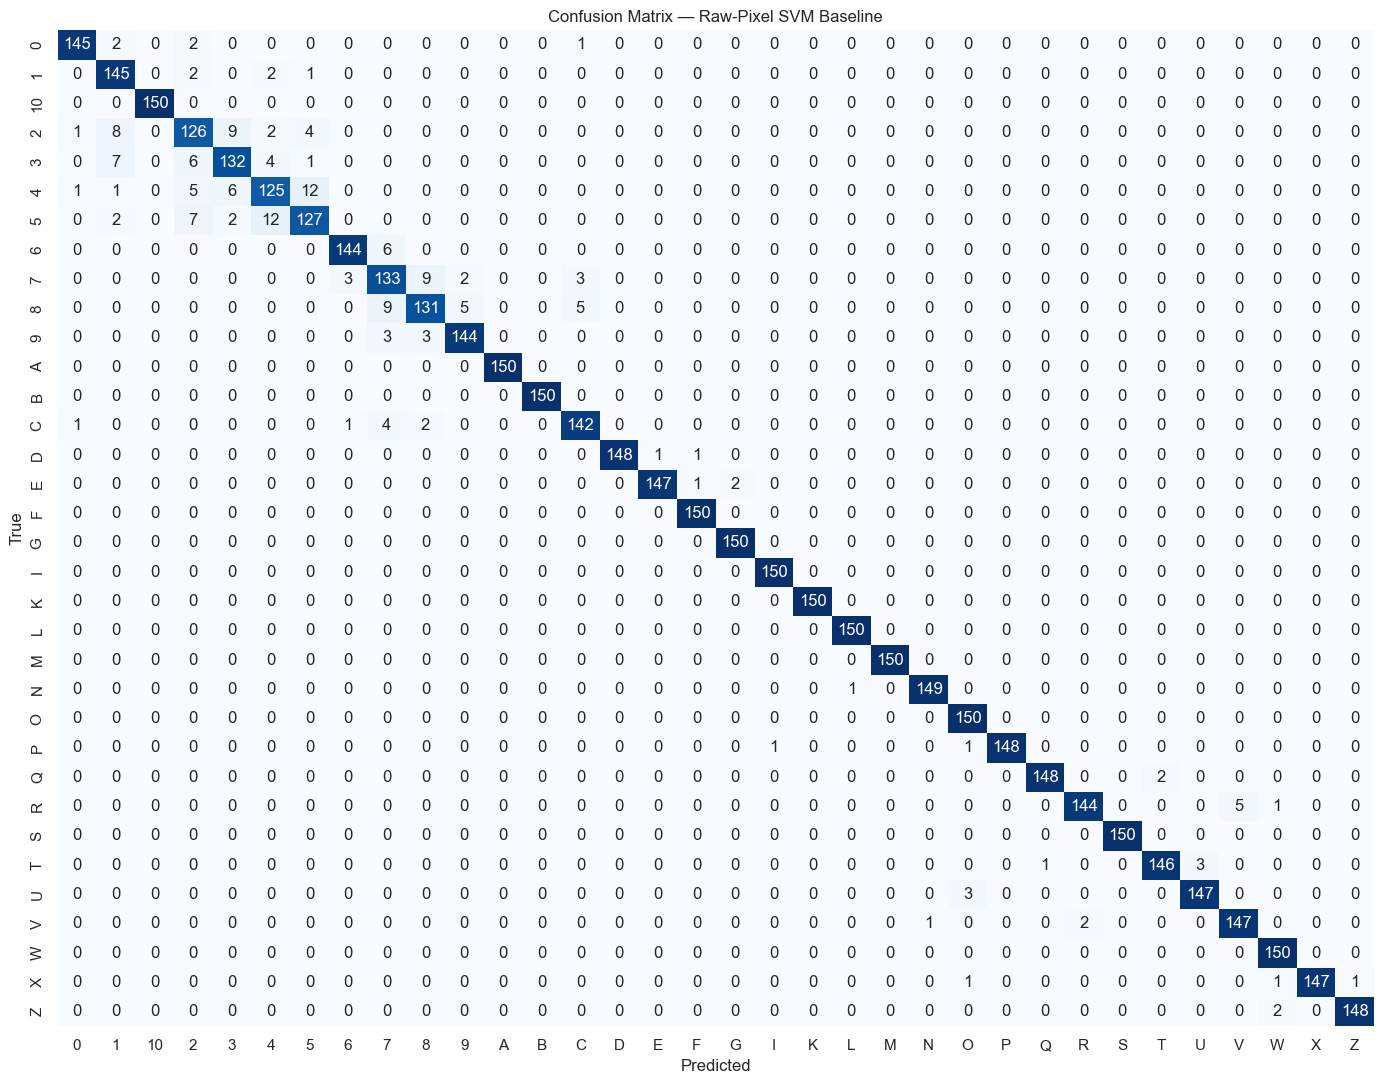


Classification report — Raw-Pixel SVM Baseline
              precision    recall  f1-score   support

           0     0.9797    0.9667    0.9732       150
           1     0.8788    0.9667    0.9206       150
          10     1.0000    1.0000    1.0000       150
           2     0.8514    0.8400    0.8456       150
           3     0.8859    0.8800    0.8829       150
           4     0.8621    0.8333    0.8475       150
           5     0.8759    0.8467    0.8610       150
           6     0.9730    0.9600    0.9664       150
           7     0.8581    0.8867    0.8721       150
           8     0.9034    0.8733    0.8881       150
           9     0.9536    0.9600    0.9568       150
           A     1.0000    1.0000    1.0000       150
           B     1.0000    1.0000    1.0000       150
           C     0.9404    0.9467    0.9435       150
           D     1.0000    0.9867    0.9933       150
           E     0.9932    0.9800    0.9866       150
           F     0.9868    1.0000

,hand_group,model,accuracy,weighted_f1,uses_raw_pixels
0,one_hand,svm_rbf,0.998746,0.998748,No
1,one_hand,mlp_sklearn,0.998746,0.998748,No
2,two_hand,svm_rbf,0.998431,0.998431,No
3,one_hand,knn,0.998119,0.998125,No
4,two_hand,random_forest,0.998038,0.998037,No
5,one_hand,random_forest,0.997492,0.997498,No
6,one_hand,mlp_keras,0.996865,0.996872,No
7,two_hand,knn,0.996862,0.996860,No
8,two_hand,mlp_sklearn,0.996469,0.996465,No
9,two_hand,mlp_keras,0.985092,0.984979,No


Saved comparison table: C:\Users\singh\Desktop\a2 i&v\edited code files\outputs\routed_keypoint_vs_raw_pixel_comparison.csv


In [21]:
#changes: Keep raw-pixel baseline for report/presentation comparison.
# It remains a combined raw-image baseline, while keypoint models are now routed
# into one-hand and two-hand versions.

def load_raw_pixel_baseline(df_idx, target_size=PIXEL_SIZE):
    Xp, yp = [], []

    for row in df_idx.itertuples(index=False):
        img = cv2.imread(row.image_path, cv2.IMREAD_GRAYSCALE)

        if img is None:
            continue

        img = cv2.resize(img, target_size, interpolation=cv2.INTER_AREA)

        Xp.append(img.flatten().astype(np.float32) / 255.0)
        yp.append(str(row.label))

    return np.array(Xp, dtype=np.float32), np.array(yp, dtype=str)


print(f'Building raw-pixel baseline ({PIXEL_SIZE[0]}x{PIXEL_SIZE[1]} grayscale)...')

X_pix, y_pix = load_raw_pixel_baseline(df_index)

# Use only labels that survived in routed one-hand/two-hand datasets.
known_labels = set(one_hand_data["classes"]) | set(two_hand_data["classes"])
mask = np.isin(y_pix, list(known_labels))

if (~mask).any():
    skipped_cls = sorted(set(y_pix[~mask]))
    print(
        f'[INFO] Pixel baseline: skipping {(~mask).sum()} images from '
        f'{len(skipped_cls)} class(es) not used in routed training: {skipped_cls}'
    )

X_pix = X_pix[mask]
y_pix = y_pix[mask]

# Separate encoder only for raw-pixel baseline.
pixel_label_encoder = LabelEncoder()
y_pix_enc = pixel_label_encoder.fit_transform(y_pix)

print(f'Raw-pixel samples: {X_pix.shape[0]}')
print(f'Raw-pixel feature dimensions: {X_pix.shape[1]}')
print(f'Raw-pixel classes: {list(pixel_label_encoder.classes_)}')

X_pix_train, X_pix_test, y_pix_train, y_pix_test = train_test_split(
    X_pix,
    y_pix_enc,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y_pix_enc
)

# PCA components must be smaller than available samples/features.
effective_pca_components = min(
    PCA_COMPONENTS,
    X_pix_train.shape[0] - 1,
    X_pix_train.shape[1] - 1
)

if effective_pca_components < 1:
    raise ValueError("Not enough raw-pixel training samples for PCA baseline.")

if effective_pca_components != PCA_COMPONENTS:
    print(
        f'[INFO] PCA_COMPONENTS adjusted from {PCA_COMPONENTS} '
        f'to {effective_pca_components} due to sample/feature limits.'
    )

baseline = Pipeline([
    ('scaler', StandardScaler(with_mean=False)),
    ('pca', PCA(n_components=effective_pca_components, random_state=RANDOM_STATE)),
    ('clf', SVC(
        kernel=PIXEL_SVM_KERNEL,
        C=PIXEL_SVM_C,
        gamma=PIXEL_SVM_GAMMA,
        random_state=RANDOM_STATE
    ))
])

baseline.fit(X_pix_train, y_pix_train)
baseline_pred = baseline.predict(X_pix_test)

pix_acc = accuracy_score(y_pix_test, baseline_pred)
pix_f1 = f1_score(y_pix_test, baseline_pred, average='weighted')

print(f'\nRaw-pixel SVM baseline')
print(f'Accuracy:    {pix_acc:.4f}')
print(f'Weighted F1: {pix_f1:.4f}')

# Save raw-pixel confusion matrix
pixel_labels_sorted = sorted(np.unique(y_pix_test))
pixel_label_names = pixel_label_encoder.inverse_transform(pixel_labels_sorted)

pixel_cm = confusion_matrix(y_pix_test, baseline_pred, labels=pixel_labels_sorted)

plt.figure(figsize=(14, 11))
sns.heatmap(
    pixel_cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=pixel_label_names,
    yticklabels=pixel_label_names,
    cbar=False
)
plt.title('Confusion Matrix — Raw-Pixel SVM Baseline')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.tight_layout()

pixel_cm_path = FIGURES_DIR / 'confusion_matrix_pixel_svm_baseline.png'
plt.savefig(pixel_cm_path, dpi=300, bbox_inches='tight')
print(f'Saved raw-pixel confusion matrix: {pixel_cm_path}')

plt.show()

print('\nClassification report — Raw-Pixel SVM Baseline')
pixel_report = classification_report(
    y_pix_test,
    baseline_pred,
    target_names=pixel_label_names,
    digits=4
)
print(pixel_report)

pixel_report_path = RESULTS_DIR / 'classification_report_pixel_svm_baseline.txt'
with open(pixel_report_path, 'w', encoding='utf-8') as f:
    f.write(pixel_report)

print(f'Saved raw-pixel classification report: {pixel_report_path}')

# Build comparison table
df_comparison = df_results.copy()
df_comparison['uses_raw_pixels'] = 'No'

pixel_row = pd.DataFrame([{
    'hand_group': 'combined_raw_pixel',
    'model': 'pixel_svm_baseline',
    'accuracy': pix_acc,
    'weighted_f1': pix_f1,
    'uses_raw_pixels': 'Yes'
}])

df_comparison = (
    pd.concat([df_comparison, pixel_row], ignore_index=True)
    .sort_values('weighted_f1', ascending=False)
    .reset_index(drop=True)
)

print('\n=== Full Comparison Table: Routed Keypoint Models vs Raw-Pixel Baseline ===')
display(df_comparison)

comparison_csv = RESULTS_DIR / 'routed_keypoint_vs_raw_pixel_comparison.csv'
df_comparison.to_csv(comparison_csv, index=False)

print(f'Saved comparison table: {comparison_csv}')

## Raw-Pixel Baseline vs Keypoint Representation Based on Hard Pairs

This section compares the privacy-preserving keypoint representation against the raw-pixel baseline for the selected hard pairs: `L/A`, `T/A`, `U/S`, and `U/E`.

The keypoint side uses the Random Forest model from the routed keypoint pipeline, because the existing hard-pair analysis is already based on Random Forest feature importance and Random Forest predictions. The raw-pixel side uses the grayscale image baseline with PCA and SVM.

This comparison helps check whether the selected hard-pair confusions appear only in the keypoint representation or also appear when using raw image pixels. If both representations struggle with the same pair, the issue may be due to visual similarity between signs. If only the keypoint representation struggles, it may suggest that some visual detail was lost during skeleton/keypoint conversion.

The comparison is based on held-out test predictions, while the hard pairs were selected from manual live webcam observations.

=== Raw-Pixel Baseline vs Keypoint Representation: Hard-Pair Comparison ===

Keypoints | L/A
  Accuracy: 1.0000  (257 samples)
  L → A: 0
  A → L: 0
  correct L: 115
  correct A: 142

Raw pixels | L/A
  Accuracy: 1.0000  (300 samples)
  L → A: 0
  A → L: 0
  correct L: 150
  correct A: 150

Keypoints | T/A
  Accuracy: 1.0000  (236 samples)
  T → A: 0
  A → T: 0
  correct T: 94
  correct A: 142

Raw pixels | T/A
  Accuracy: 0.9867  (300 samples)
  T → A: 0
  A → T: 0
  correct T: 146
  correct A: 150

Keypoints | U/S
  Accuracy: 0.9888  (178 samples)
  U → S: 0
  S → U: 0
  correct U: 96
  correct S: 80

Raw pixels | U/S
  Accuracy: 0.9900  (300 samples)
  U → S: 0
  S → U: 0
  correct U: 147
  correct S: 150

Keypoints | U/E
  Accuracy: 0.9915  (235 samples)
  U → E: 2
  E → U: 0
  correct U: 96
  correct E: 137

Raw pixels | U/E
  Accuracy: 0.9800  (300 samples)
  U → E: 0
  E → U: 0
  correct U: 147
  correct E: 147

=== Hard-Pair Representation Comparison Table ===


,pair,representation,model,accuracy,test_samples,L_to_A,A_to_L,correct_L,correct_A,T_to_A,A_to_T,correct_T,U_to_S,S_to_U,correct_U,correct_S,U_to_E,E_to_U,correct_E
0,L/A,Keypoints,Random Forest,1.000000,257,0.0,0.0,115.0,142.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,L/A,Raw pixels,PCA + SVM,1.000000,300,0.0,0.0,150.0,150.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,T/A,Keypoints,Random Forest,1.000000,236,NaN,NaN,NaN,142.0,0.0,0.0,94.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,T/A,Raw pixels,PCA + SVM,0.986667,300,NaN,NaN,NaN,150.0,0.0,0.0,146.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,U/S,Keypoints,Random Forest,0.988764,178,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,96.0,80.0,NaN,NaN,NaN
5,U/S,Raw pixels,PCA + SVM,0.990000,300,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,147.0,150.0,NaN,NaN,NaN
6,U/E,Keypoints,Random Forest,0.991489,235,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,96.0,NaN,2.0,0.0,137.0
7,U/E,Raw pixels,PCA + SVM,0.980000,300,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,147.0,NaN,0.0,0.0,147.0


Saved hard-pair representation comparison: C:\Users\singh\Desktop\a2 i&v\edited code files\outputs\hard_pair_raw_pixel_vs_keypoints_comparison.csv
Saved hard-pair representation plot: C:\Users\singh\Desktop\a2 i&v\edited code files\outputs\hard_pair_raw_pixel_vs_keypoints_accuracy.png


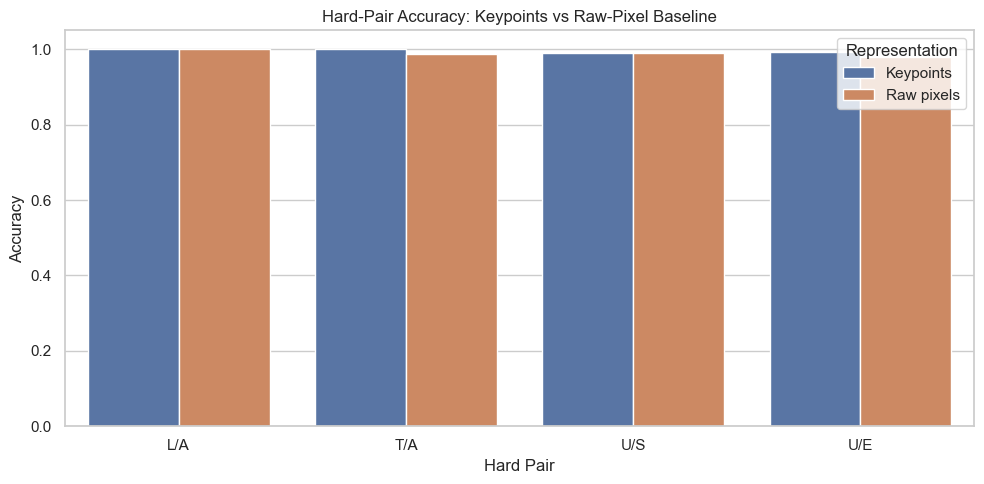

In [26]:
#added: Compare raw-pixel baseline vs keypoint representation for selected hard pairs.
# This uses the same HARD_PAIRS list used in the hard-pair analysis:
# L/A, T/A, U/S, U/E.

print("=== Raw-Pixel Baseline vs Keypoint Representation: Hard-Pair Comparison ===")

# ── Safety checks ─────────────────────────────────────────────────────────────
required_vars = [
    "HARD_PAIRS",
    "two_hand_data",
    "baseline_pred",
    "y_pix_test",
    "pixel_label_encoder",
    "OUTPUTS_DIR"
]

missing_vars = [v for v in required_vars if v not in globals()]
if missing_vars:
    raise NameError(f"Missing required variable(s): {missing_vars}")

if "random_forest" not in two_hand_data.get("predictions", {}):
    raise KeyError("two_hand_data['predictions']['random_forest'] not found. Run the evaluation cell first.")

# ── Keypoint representation predictions: Random Forest on two-hand keypoints ──
kp_true_lbl = two_hand_data["label_encoder"].inverse_transform(two_hand_data["y_test"])
kp_pred_lbl = two_hand_data["label_encoder"].inverse_transform(
    two_hand_data["predictions"]["random_forest"]
)

# ── Raw-pixel baseline predictions: PCA + SVM baseline ────────────────────────
pix_true_lbl = pixel_label_encoder.inverse_transform(y_pix_test)
pix_pred_lbl = pixel_label_encoder.inverse_transform(baseline_pred)

comparison_rows = []


def analyse_pair_for_representation(
    pair,
    y_true_lbl,
    y_pred_lbl,
    representation_name,
    model_name
):
    """
    Analyse one hard pair for one representation.
    Returns one row with pair accuracy and directional confusion counts.
    """
    a, b = pair

    mask = np.isin(y_true_lbl, [a, b])

    if mask.sum() == 0:
        print(f"{representation_name} | {a}/{b}: no test samples")
        return None

    pair_true = y_true_lbl[mask]
    pair_pred = y_pred_lbl[mask]

    acc = accuracy_score(pair_true, pair_pred)

    a_to_b = int(((pair_true == a) & (pair_pred == b)).sum())
    b_to_a = int(((pair_true == b) & (pair_pred == a)).sum())
    correct_a = int(((pair_true == a) & (pair_pred == a)).sum())
    correct_b = int(((pair_true == b) & (pair_pred == b)).sum())

    print(f"\n{representation_name} | {a}/{b}")
    print(f"  Accuracy: {acc:.4f}  ({mask.sum()} samples)")
    print(f"  {a} → {b}: {a_to_b}")
    print(f"  {b} → {a}: {b_to_a}")
    print(f"  correct {a}: {correct_a}")
    print(f"  correct {b}: {correct_b}")

    return {
        "pair": f"{a}/{b}",
        "representation": representation_name,
        "model": model_name,
        "accuracy": acc,
        "test_samples": int(mask.sum()),
        f"{a}_to_{b}": a_to_b,
        f"{b}_to_{a}": b_to_a,
        f"correct_{a}": correct_a,
        f"correct_{b}": correct_b
    }


# ── Run comparison for each selected hard pair ────────────────────────────────
for pair in HARD_PAIRS:
    a, b = pair

    # Skip if pair is not present in two-hand routed keypoint classes.
    # All selected pairs should be two-hand signs, but this keeps the cell safe.
    if a not in two_hand_data["classes"] or b not in two_hand_data["classes"]:
        print(f"\n{a}/{b}: skipped — pair not present in two_hand_data classes")
        continue

    kp_row = analyse_pair_for_representation(
        pair=pair,
        y_true_lbl=kp_true_lbl,
        y_pred_lbl=kp_pred_lbl,
        representation_name="Keypoints",
        model_name="Random Forest"
    )

    pix_row = analyse_pair_for_representation(
        pair=pair,
        y_true_lbl=pix_true_lbl,
        y_pred_lbl=pix_pred_lbl,
        representation_name="Raw pixels",
        model_name="PCA + SVM"
    )

    if kp_row is not None:
        comparison_rows.append(kp_row)

    if pix_row is not None:
        comparison_rows.append(pix_row)


df_hard_pair_representation_comparison = pd.DataFrame(comparison_rows)

if df_hard_pair_representation_comparison.empty:
    print("\nNo hard-pair comparison rows were created. Check HARD_PAIRS and test labels.")
else:
    print("\n=== Hard-Pair Representation Comparison Table ===")
    display(df_hard_pair_representation_comparison)

    # Save comparison table
    hard_pair_comparison_csv = RESULTS_DIR / "hard_pair_raw_pixel_vs_keypoints_comparison.csv"
    df_hard_pair_representation_comparison.to_csv(hard_pair_comparison_csv, index=False)
    print(f"Saved hard-pair representation comparison: {hard_pair_comparison_csv}")

    # ── Plot comparison in the same simple style as existing notebook charts ──
    plt.figure(figsize=(10, 5))
    sns.barplot(
        data=df_hard_pair_representation_comparison,
        x="pair",
        y="accuracy",
        hue="representation"
    )

    plt.title("Hard-Pair Accuracy: Keypoints vs Raw-Pixel Baseline")
    plt.xlabel("Hard Pair")
    plt.ylabel("Accuracy")
    plt.ylim(0, 1.05)
    plt.legend(title="Representation")
    plt.tight_layout()

    hard_pair_plot_path = FIGURES_DIR / "hard_pair_raw_pixel_vs_keypoints_accuracy.png"
    plt.savefig(hard_pair_plot_path, dpi=300, bbox_inches="tight")
    print(f"Saved hard-pair representation plot: {hard_pair_plot_path}")

    plt.show()

---
## Section 13 — Privacy Visualisation

Saved privacy comparison plot: C:\Users\singh\Desktop\a2 i&v\edited code files\outputs\privacy_comparison_routed.png


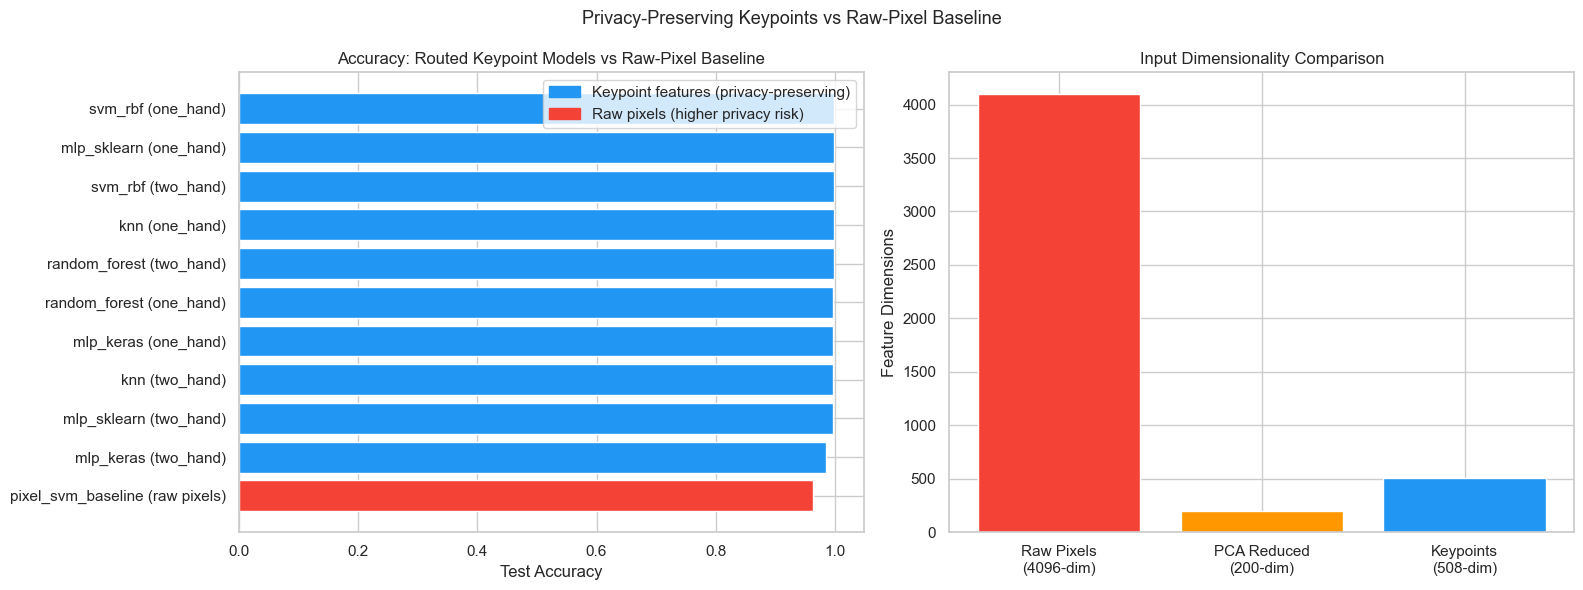

In [22]:
#changes: Update privacy comparison plot for routed one-hand/two-hand model results.
#added: Display hand_group with model name so one-hand and two-hand results are clear.

df_plot = df_comparison.copy()

df_plot["display_name"] = df_plot.apply(
    lambda row: f"{row['model']} ({row['hand_group']})"
    if row["hand_group"] != "combined_raw_pixel"
    else "pixel_svm_baseline (raw pixels)",
    axis=1
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Panel 1 — accuracy grouped by privacy cost
bar_colors = [
    "#F44336" if v == "Yes" else "#2196F3"
    for v in df_plot["uses_raw_pixels"]
]

axes[0].barh(
    df_plot["display_name"],
    df_plot["accuracy"],
    color=bar_colors
)

axes[0].set_xlabel("Test Accuracy")
axes[0].set_title("Accuracy: Routed Keypoint Models vs Raw-Pixel Baseline")
axes[0].invert_yaxis()

axes[0].legend(handles=[
    Patch(color="#2196F3", label="Keypoint features (privacy-preserving)"),
    Patch(color="#F44336", label="Raw pixels (higher privacy risk)")
])

# Panel 2 — feature dimensionality
raw_dims = PIXEL_SIZE[0] * PIXEL_SIZE[1]
keypoint_dims = X.shape[1]

# Use adjusted PCA value if the previous cell changed it
pca_dims = effective_pca_components if "effective_pca_components" in globals() else PCA_COMPONENTS

dim_labels = [
    f"Raw Pixels\n({raw_dims}-dim)",
    f"PCA Reduced\n({pca_dims}-dim)",
    f"Keypoints\n({keypoint_dims}-dim)"
]

dim_values = [raw_dims, pca_dims, keypoint_dims]
dim_colors = ["#F44336", "#FF9800", "#2196F3"]

axes[1].bar(dim_labels, dim_values, color=dim_colors)
axes[1].set_ylabel("Feature Dimensions")
axes[1].set_title("Input Dimensionality Comparison")

plt.suptitle(
    "Privacy-Preserving Keypoints vs Raw-Pixel Baseline",
    fontsize=13
)

plt.tight_layout()

privacy_plot_path = FIGURES_DIR / "privacy_comparison_routed.png"
plt.savefig(privacy_plot_path, dpi=300, bbox_inches="tight")

print(f"Saved privacy comparison plot: {privacy_plot_path}")

plt.show()

---
## Section 14 — Model Export

In [23]:
#changes: Export routed one-hand and two-hand model files for backend routing.
#added: Save sklearn routed models, Keras routed models, scalers, label files, raw-pixel baseline, and model_results.json.

import json

all_groups = [one_hand_data, two_hand_data]

results_dict = {}

# ── Save sklearn routed models ────────────────────────────────────────────────
for group in all_groups:
    hand_group = group["name"]

    for model_name, clf in group["models"].items():
        routed_name = f"{model_name}_{hand_group}"
        out_path = CHECKPOINTS_DIR / f"{routed_name}.joblib"

        joblib.dump({
            "model_name": model_name,
            "hand_group": hand_group,
            "routed_model_name": routed_name,
            "model": clf,
            "classes": group["label_encoder"].classes_.tolist(),
            "feature_version": FEATURE_VERSION
        }, out_path)

        row = group["results_df"][group["results_df"]["model"] == model_name].iloc[0]

        results_dict[routed_name] = {
            "base_model": model_name,
            "hand_group": hand_group,
            "accuracy": float(row["accuracy"]),
            "weighted_f1": float(row["weighted_f1"]),
            "input_type": "keypoints"
        }

        print(f"Saved sklearn routed model: {out_path}")


# ── Save Keras routed models ──────────────────────────────────────────────────
for group in all_groups:
    hand_group = group["name"]

    keras_model_path  = CHECKPOINTS_DIR / f"mlp_keras_{hand_group}.h5"
    keras_scaler_path = CHECKPOINTS_DIR / f"keras_scaler_{hand_group}.pkl"
    keras_labels_path = CHECKPOINTS_DIR / f"label_classes_{hand_group}.npy"

    group["keras_model"].save(keras_model_path)
    joblib.dump(group["keras_scaler"], keras_scaler_path)
    np.save(keras_labels_path, group["label_encoder"].classes_)

    row = group["results_df"][group["results_df"]["model"] == "mlp_keras"].iloc[0]

    routed_name = f"mlp_keras_{hand_group}"

    results_dict[routed_name] = {
        "base_model": "mlp_keras",
        "hand_group": hand_group,
        "accuracy": float(row["accuracy"]),
        "weighted_f1": float(row["weighted_f1"]),
        "input_type": "keypoints"
    }

    print(f"Saved Keras routed model: {keras_model_path}")
    print(f"Saved Keras scaler: {keras_scaler_path}")
    print(f"Saved Keras labels: {keras_labels_path}")


# ── Save raw-pixel baseline model for report / optional later use ─────────────
# This does not affect the current keypoint router yet.
if "baseline" in globals() and "pixel_label_encoder" in globals():
    raw_pixel_path = CHECKPOINTS_DIR / "pixel_svm_baseline.joblib"

    joblib.dump({
        "model_name": "pixel_svm_baseline",
        "model": baseline,
        "classes": pixel_label_encoder.classes_.tolist(),
        "pixel_size": PIXEL_SIZE,
        "pca_components": effective_pca_components if "effective_pca_components" in globals() else PCA_COMPONENTS,
        "input_type": "raw_pixels"
    }, raw_pixel_path)

    results_dict["pixel_svm_baseline"] = {
        "base_model": "pixel_svm_baseline",
        "hand_group": "combined_raw_pixel",
        "accuracy": float(pix_acc),
        "weighted_f1": float(pix_f1),
        "input_type": "raw_pixels"
    }

    print(f"Saved raw-pixel baseline: {raw_pixel_path}")
else:
    print("[INFO] Raw-pixel baseline variables not found, so pixel_svm_baseline.joblib was not saved.")


# ── Save best routed sklearn model as optional canonical bundle ───────────────
# This is not the main backend router file, but it is useful as a record of the best sklearn result.
sklearn_only = df_results[df_results["model"] != "mlp_keras"].copy()

if not sklearn_only.empty:
    best_row = sklearn_only.sort_values("weighted_f1", ascending=False).iloc[0]
    best_hand_group = best_row["hand_group"]
    best_model_name = best_row["model"]
    best_model = (
        one_hand_data["models"][best_model_name]
        if best_hand_group == "one_hand"
        else two_hand_data["models"][best_model_name]
    )
    best_group = one_hand_data if best_hand_group == "one_hand" else two_hand_data

    joblib.dump({
        "model_name": best_model_name,
        "hand_group": best_hand_group,
        "routed_model_name": f"{best_model_name}_{best_hand_group}",
        "model": best_model,
        "classes": best_group["label_encoder"].classes_.tolist(),
        "feature_version": FEATURE_VERSION
    }, MODEL_JOBLIB)

    print(f"Saved optional best routed sklearn bundle: {MODEL_JOBLIB}")
    print(f"Best sklearn routed model: {best_model_name}_{best_hand_group}")


# ── Save model results as JSON for backend /models endpoint ───────────────────
with open(MODEL_RESULTS_JSON, "w", encoding="utf-8") as f:
    json.dump(results_dict, f, indent=2)

print(f"Saved routed model results JSON: {MODEL_RESULTS_JSON}")


# ── Save final comparison CSVs again for safety ───────────────────────────────
df_results.to_csv(ROUTED_RESULTS_CSV, index=False)

if "df_comparison" in globals():
    df_comparison.to_csv(RESULTS_DIR / "final_model_comparison_with_raw_pixel.csv", index=False)

print("\nFinal checkpoint files created:")
for p in sorted(CHECKPOINTS_DIR.glob("*")):
    if p.suffix.lower() in [".joblib", ".h5", ".npy", ".pkl", ".json"]:
        print(" -", p.name)

Saved sklearn routed model: C:\Users\singh\Desktop\a2 i&v\edited code files\checkpoints\svm_rbf_one_hand.joblib
Saved sklearn routed model: C:\Users\singh\Desktop\a2 i&v\edited code files\checkpoints\random_forest_one_hand.joblib
Saved sklearn routed model: C:\Users\singh\Desktop\a2 i&v\edited code files\checkpoints\knn_one_hand.joblib
Saved sklearn routed model: C:\Users\singh\Desktop\a2 i&v\edited code files\checkpoints\mlp_sklearn_one_hand.joblib
Saved sklearn routed model: C:\Users\singh\Desktop\a2 i&v\edited code files\checkpoints\svm_rbf_two_hand.joblib


Saved sklearn routed model: C:\Users\singh\Desktop\a2 i&v\edited code files\checkpoints\random_forest_two_hand.joblib
Saved sklearn routed model: C:\Users\singh\Desktop\a2 i&v\edited code files\checkpoints\knn_two_hand.joblib
Saved sklearn routed model: C:\Users\singh\Desktop\a2 i&v\edited code files\checkpoints\mlp_sklearn_two_hand.joblib


Saved Keras routed model: C:\Users\singh\Desktop\a2 i&v\edited code files\checkpoints\mlp_keras_one_hand.h5
Saved Keras scaler: C:\Users\singh\Desktop\a2 i&v\edited code files\checkpoints\keras_scaler_one_hand.pkl
Saved Keras labels: C:\Users\singh\Desktop\a2 i&v\edited code files\checkpoints\label_classes_one_hand.npy
Saved Keras routed model: C:\Users\singh\Desktop\a2 i&v\edited code files\checkpoints\mlp_keras_two_hand.h5
Saved Keras scaler: C:\Users\singh\Desktop\a2 i&v\edited code files\checkpoints\keras_scaler_two_hand.pkl
Saved Keras labels: C:\Users\singh\Desktop\a2 i&v\edited code files\checkpoints\label_classes_two_hand.npy
Saved raw-pixel baseline: C:\Users\singh\Desktop\a2 i&v\edited code files\checkpoints\pixel_svm_baseline.joblib
Saved optional best routed sklearn bundle: C:\Users\singh\Desktop\a2 i&v\edited code files\checkpoints\nzsl_privacy_model.joblib
Best sklearn routed model: svm_rbf_one_hand
Saved routed model results JSON: C:\Users\singh\Desktop\a2 i&v\edited cod

---
## Section 14b — Skeleton Reference PNG Generation

Generates one skeleton PNG per class and saves them to `backend/static/signs/`.  
These images are served by the API for the **sign reference panel** in the web frontend — showing what the correctly-formed sign looks like as a privacy-safe skeleton, not a raw photo.

Run this cell once after Section 14. Re-run only if the dataset changes.

In [24]:
# ── Skeleton reference PNGs for web frontend sign reference panel ─────────────
# Picks the best-quality sample per class (same logic as Section 4 grid),
# draws the skeleton on a 400×400 black canvas, saves as backend/static/signs/{cls}.png.
# One-time operation — re-run only when the dataset changes.

SIGNS_DIR       = _PROJECT_ROOT / 'backend' / 'static' / 'signs'
SIGN_CANVAS_PX  = 400   # canvas size in pixels
SIGN_SCAN_LIMIT = 30    # max images to scan per class

SIGNS_DIR.mkdir(parents=True, exist_ok=True)

_exp = {cls: 2 for cls in TWO_HAND_CLASSES}
_exp.update({cls: 1 for cls in ONE_HAND_CLASSES})

saved, skipped = [], []

with mp_hands.Hands(
    static_image_mode=True,
    max_num_hands=MP_MAX_HANDS,
    min_detection_confidence=MP_DETECTION_CONF
) as hands:
    for cls in ALL_CLASSES:
        subfolder = '2_HAND_DATASET' if cls in TWO_HAND_CLASSES else '1_HAND_DATASET'
        cls_dir   = DATASET_DIR / subfolder / cls
        if not cls_dir.exists():
            skipped.append(cls); continue
        imgs = sorted([p for p in cls_dir.rglob('*') if p.suffix.lower() in IMG_EXTS])
        if not imgs:
            skipped.append(cls); continue

        target      = _exp.get(cls, 1)
        best_canvas = None
        best_count  = -1

        for img_path in imgs[:SIGN_SCAN_LIMIT]:
            img_bgr = cv2.imread(str(img_path))
            if img_bgr is None:
                continue
            result = hands.process(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB))
            del img_bgr
            n = len(result.multi_hand_landmarks) if result.multi_hand_landmarks else 0

            canvas = np.zeros((SIGN_CANVAS_PX, SIGN_CANVAS_PX, 3), dtype=np.uint8)
            if result.multi_hand_landmarks:
                for hand_lm in result.multi_hand_landmarks:
                    mp_draw.draw_landmarks(
                        canvas, hand_lm,
                        mp_hands.HAND_CONNECTIONS,
                        mp_styles.get_default_hand_landmarks_style(),
                        mp_styles.get_default_hand_connections_style()
                    )
            if n > best_count:
                best_count, best_canvas = n, canvas.copy()
            if n >= target:
                break

        if best_canvas is not None:
            cv2.imwrite(str(SIGNS_DIR / f'{cls}.png'), best_canvas)
            saved.append(cls)
        else:
            skipped.append(cls)

print(f'Saved {len(saved)} skeleton reference PNGs → {SIGNS_DIR}')
if skipped:
    print(f'Skipped (no images found): {skipped}')

c:\Users\singh\Desktop\a2 i&v\edited code files\.venv\lib\site-packages\google\protobuf\symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '


Saved 34 skeleton reference PNGs → C:\Users\singh\Desktop\a2 i&v\edited code files\backend\static\signs


---
## Section 15 — Inference Sanity Check

In [25]:
#changes: Sanity check for routed one-hand/two-hand prediction.
# This tests the same logic the backend will use later.

sample_path = df_index.iloc[0]['image_path'] if len(df_index) else None

if sample_path:
    true_label = str(df_index.iloc[0]["label"])

    with mp_hands.Hands(
        static_image_mode=True,
        max_num_hands=MP_MAX_HANDS,
        min_detection_confidence=MP_DETECTION_CONF
    ) as hands:
        sample_img = cv2.imread(sample_path)

        if sample_img is None:
            feats = None
        else:
            feats = extract_feature_vector_from_image(sample_img, hands)

        del sample_img

    if feats is not None:
        inferred_hand_group = infer_hand_group_from_features(feats)

        # Use SVM as a simple sanity-test model.
        test_model_key = "svm_rbf"
        routed_checkpoint = routed_checkpoint_path(test_model_key, inferred_hand_group)

        print(f"Sample image: {sample_path}")
        print(f"True label: {true_label}")
        print(f"Inferred hand group: {inferred_hand_group}")
        print(f"Loading checkpoint: {routed_checkpoint.name}")

        if not routed_checkpoint.exists():
            raise FileNotFoundError(f"Checkpoint not found: {routed_checkpoint}")

        loaded = joblib.load(routed_checkpoint)

        clf = loaded["model"]
        classes = loaded["classes"]

        raw_pred = clf.predict([feats])[0]

        pred_lbl = classes[int(raw_pred)] if isinstance(raw_pred, (int, np.integer)) else str(raw_pred)

        if hasattr(clf, "predict_proba"):
            conf = float(np.max(clf.predict_proba([feats])))
            print(f"Predicted: {pred_lbl}  (confidence = {conf:.3f})")
        else:
            print(f"Predicted: {pred_lbl}")

        print(f"Routed model used: {loaded.get('routed_model_name', routed_checkpoint.stem)}")

    else:
        print("Could not detect any hands in sample image.")
else:
    print("No images indexed — check DATASET_DIR.")

Sample image: C:\Users\singh\Desktop\a2 i&v\edited code files\data\raw\BSL_Dataset\2_HAND_DATASET\A\10.png
True label: A
Inferred hand group: two_hand
Loading checkpoint: svm_rbf_two_hand.joblib
Predicted: A  (confidence = 0.927)
Routed model used: svm_rbf_two_hand


## Section 16 — Routed Web Demo Deployment

The trained models are used in a local web-based NZSL/BSL fingerspelling demo.  
The demo is run through a FastAPI backend and an HTML frontend rather than a standalone OpenCV script.

The exported checkpoint files are loaded from the `checkpoints/` folder.  
For each selected model, the backend automatically routes the prediction to the correct one-hand or two-hand checkpoint based on the incoming 508-dimensional keypoint vector.

Example routed checkpoint files:

```text
checkpoints/
├── svm_rbf_one_hand.joblib
├── svm_rbf_two_hand.joblib
├── random_forest_one_hand.joblib
├── random_forest_two_hand.joblib
├── knn_one_hand.joblib
├── knn_two_hand.joblib
├── mlp_sklearn_one_hand.joblib
├── mlp_sklearn_two_hand.joblib
├── mlp_keras_one_hand.h5
├── mlp_keras_two_hand.h5
├── keras_scaler_one_hand.pkl
├── keras_scaler_two_hand.pkl
├── label_classes_one_hand.npy
├── label_classes_two_hand.npy
└── model_results.json